# SocioBuzz - Social Media Trend Predictor 
# [FYP - Final Year Project]

## Install Necessary Packages

In [1]:
!pip install streamlit pandas numpy scikit-learn xgboost shap vaderSentiment plotly joblib seaborn matplotlib

## Import Necessary Libraries

In [2]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

warnings.filterwarnings("ignore")

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from sklearn.model_selection import (train_test_split, StratifiedKFold, KFold, cross_val_score, cross_validate, GridSearchCV)
from sklearn.preprocessing import (StandardScaler, OneHotEncoder, LabelEncoder, label_binarize)
from sklearn.dummy import DummyClassifier
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, recall_score, roc_curve, auc,
mean_squared_error, mean_absolute_error, r2_score)

from scipy import stats
from xgboost import XGBClassifier, XGBRegressor

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 50)
plt.rcParams.update({"figure.dpi": 120, "axes.titleweight": "bold"})

## Paths

In [3]:
# Paths
Base_path            = os.path.abspath(os.path.join(os.getcwd(), ".."))
Data_directory_path  = os.path.join(Base_path, "Datasets")
Other_imp_byproducts = os.path.join(Base_path, "Other_imp_byproducts")
os.makedirs(Other_imp_byproducts, exist_ok=True)

merged_path = os.path.join(Data_directory_path, "merged_dataset.csv")

Files = {
    "Data1": os.path.join(Data_directory_path, "Social_Media_Engagement_Dataset.csv"),
    "Data2": os.path.join(Data_directory_path, "Cleaned_Viral_Social_Media_Trends.csv"),
}

# Check cols for dtype, unique with example
for name, path in Files.items():
    if not os.path.exists(path):
        print(f"{name}: does not exist @ {path}")
        continue
    temp = pd.read_csv(path)
    print(f"\n{'~'*27}")
    print(f"{name}: {temp.shape[0]} rows x {temp.shape[1]} cols")
    print(f"{'~'*27}")
    for col in temp.columns:
        sample = temp[col].dropna().iloc[0] if len(temp[col].dropna()) > 0 else "N/A"
        print(f"  {col:<35} dtype={str(temp[col].dtype):<10} unique={temp[col].nunique():<6} sample={repr(sample)}")

# Assign files
df1 = pd.read_csv(Files["Data1"])
df2 = pd.read_csv(Files["Data2"])

# Print shape of data 1 & 2
print(f"\nData1 shape: {df1.shape}  |  Data2 shape: {df2.shape}")


~~~~~~~~~~~~~~~~~~~~~~~~~~~
Data1: 12000 rows x 28 cols
~~~~~~~~~~~~~~~~~~~~~~~~~~~
  post_id                             dtype=object     unique=12000  sample='kcqbs6hxybia'
  timestamp                           dtype=object     unique=11997  sample='2024-12-09 11:26:15'
  day_of_week                         dtype=object     unique=7      sample='Monday'
  platform                            dtype=object     unique=5      sample='Instagram'
  user_id                             dtype=object     unique=12000  sample='user_52nwb0a6'
  location                            dtype=object     unique=33     sample='Melbourne, Australia'
  language                            dtype=object     unique=10     sample='pt'
  text_content                        dtype=object     unique=11997  sample='Just tried the Chromebook from Google. Best purchase ever. #Food Really interested in hearing your thoughts!'
  hashtags                            dtype=object     unique=4490   sample='#Food'
  mentions

## Helper Functions

In [4]:
sia = SentimentIntensityAnalyzer()

# Hashtag extractor
def primary_hashtag_extractor(s):
    if pd.isna(s) or not str(s).strip(): return "#Other"
    for p in [p.strip() for p in str(s).split(",")]:
        p = p if p.startswith("#") else f"#{p}"
        if p != "#": return p
    return "#Other"

# Hashtag counter
def hashtag_counter(s):
    if pd.isna(s) or not str(s).strip(): return 1
    return max(1, str(s).count(",") + 1)

# Compute vader score to see if its positive or negative
def compute_vader_score(text):
    if pd.isna(text) or not str(text).strip(): return 0.0
    return sia.polarity_scores(str(text))["compound"]

# Infer topic category
def topic_categorisation(text):
    if not text or not str(text).strip():
        return "General"
    t = str(text).lower().replace("#", "").replace(",", " ")

    # Score each category
    scores = {
        "Pricing":         0,
        "Product":         0,
        "CustomerService": 0,
        "Event":           0,
        "Announcement":    0,
        "General":         0,
    }

    #key words
    pricing_key = ["price","cost","discount","offer","deal","sale","cheap",
                  "affordable","budget","promo","specialoffer","bestvalue","exclusive"]
    product_key = ["product","launch","new","feature","release","buy","review",
                  "unbox","gaming","tech","apple","samsung","asus","gadget",
                  "phone","laptop","productlaunch","newrelease","musthave","quality"]
    customerservice_key = ["help","support","issue","problem","complaint","fix","broken",
                          "error","refund","return","customerservice","feedback"]
    event_key = ["event","live","join","webinar","concert","show","tonight",
                "attend","meetup","challenge","dance","music","comedy","viral"]
    announcement_key = ["announce","news","update","introducing","reveal","breaking",
                       "launched","innovation","trendalert","trending","newrelease"]
    general_key = ["fashion","beauty","food","health","lifestyle","travel",
                  "fitness","education","eco","sustainable","premium","culture"]

    for w in t.split():
        if w in pricing_key:
            scores["Pricing"] += 1
        if w in product_key:
            scores["Product"] += 1
        if w in customerservice_key:
            scores["CustomerService"] += 1
        if w in event_key:
            scores["Event"] += 1
        if w in announcement_key:
            scores["Announcement"] += 1
        if w in general_key:
            scores["General"] += 1

    best = max(scores, key=scores.get)
    # If tied or all zero will be treated as general
    return best if scores[best] > 0 else "General"

## Data Preprocesing

### Process Data 1

In [5]:
d1 = df1.copy()
d1["timestamp"] = pd.to_datetime(d1["timestamp"], format="mixed", errors="coerce")
d1["hour_of_day"] = d1["timestamp"].dt.hour
d1["primary_hashtag"] = d1["hashtags"].apply(primary_hashtag_extractor)
d1["num_of_hashtags"] = d1["hashtags"].apply(hashtag_counter)
d1["hashtag_len"] = d1["hashtags"].str.len()
d1["vader_compound"] = d1["text_content"].apply(compute_vader_score)
d1["content_type"] = "Post"
d1["region"] = "Unknown"
d1 = d1.rename(columns={"likes_count":"likes","shares_count":"shares","comments_count":"comments"})
d1["Engagement_Level"] = np.nan
d1["source"] = "df1"

print(f"{'~'*27}")
print(f"Data 1 Processed: {d1.shape}")
print(f"Platforms : {sorted(d1['platform'].unique())}")
print(f"Date range: {d1['timestamp'].min().date()} -> {d1['timestamp'].max().date()}")
print(f"{'~'*27}")

~~~~~~~~~~~~~~~~~~~~~~~~~~~
Data 1 Processed: (12000, 37)
Platforms : ['Facebook', 'Instagram', 'Reddit', 'Twitter', 'YouTube']
Date range: 2024-05-01 -> 2025-04-30
~~~~~~~~~~~~~~~~~~~~~~~~~~~


### Process Data 2

In [6]:
d2 = df2.copy()
d2 = d2.rename(columns={
    "Post_Date":"timestamp","Platform":"platform","Hashtag":"primary_hashtag",
    "Content_Type":"content_type","Region":"region","Views":"impressions",
    "Likes":"likes","Shares":"shares","Comments":"comments","Engagement_Level":"Engagement_Level",
})
d2["timestamp"] = pd.to_datetime(d2["timestamp"], errors="coerce").fillna(pd.Timestamp("2023-01-01"))
d2["hour_of_day"] = d2["timestamp"].dt.hour
d2["day_of_week"] = d2["timestamp"].dt.day_name()
d2["num_of_hashtags"] = d2["primary_hashtag"].apply(hashtag_counter)
d2["hashtag_len"] = d2["primary_hashtag"].str.len()
d2["vader_compound"] = 0.0
for col in ["sentiment_score","sentiment_label","emotion_type","toxicity_score",
            "topic_category","campaign_name","campaign_phase","brand_name",
            "user_past_sentiment_avg","user_engagement_growth","buzz_change_rate","engagement_rate"]:
    d2[col] = np.nan
d2["hashtags"] = d2["primary_hashtag"]
d2["source"] = "df2"

# Infer topic category from hashtag text instead of leaving as NaN
d2["topic_category"] = d2["primary_hashtag"].apply(topic_categorisation)

print(f"{'~'*27}")
print(f"df2 Topic Distribution after inference:")
print(d2["topic_category"].value_counts().to_string())
print(f"{'~'*27}")

print(f"\n{'~'*27}")
print(f"Data 2 Processed: {d2.shape}")
print(f"Platforms : {sorted(d2['platform'].unique())}")
print(f"{'~'*27}")

~~~~~~~~~~~~~~~~~~~~~~~~~~~
df2 Topic Distribution after inference:
topic_category
Event      2482
General    1548
Product     970
~~~~~~~~~~~~~~~~~~~~~~~~~~~

~~~~~~~~~~~~~~~~~~~~~~~~~~~
Data 2 Processed: (5000, 30)
Platforms : ['Instagram', 'TikTok', 'Twitter', 'YouTube']
~~~~~~~~~~~~~~~~~~~~~~~~~~~


### Merge Datasets

In [7]:
# Necessary columns in both datasets
merged_cols = [
    "timestamp","platform","day_of_week","hour_of_day",
    "primary_hashtag","num_of_hashtags","hashtag_len","content_type","region",
    "sentiment_score","sentiment_label","emotion_type","toxicity_score","vader_compound",
    "topic_category","campaign_name","campaign_phase","brand_name",
    "likes","shares","comments","impressions","engagement_rate",
    "user_past_sentiment_avg","user_engagement_growth","buzz_change_rate",
    "Engagement_Level","source"
]

# Merge datasets d1 & d2
d1_merged = d1[[c for c in merged_cols if c in d1.columns]].copy()
d2_merged = d2[[c for c in merged_cols if c in d2.columns]].copy()
df = pd.concat([d1_merged, d2_merged], ignore_index=True)

print(f"{'~'*27}")
print(f"Merged Dataset: {df.shape}")
print(f"\nBreakdown of source:\n {df['source'].value_counts().to_string()}")
print(f"\nBreakdown of platform:\n {df['platform'].value_counts().to_string()}")
print(f"{'~'*27}")

~~~~~~~~~~~~~~~~~~~~~~~~~~~
Merged Dataset: (17000, 28)

Breakdown of source:
 source
df1    12000
df2     5000

Breakdown of platform:
 platform
YouTube      3760
Twitter      3610
Instagram    3567
Facebook     2431
Reddit       2372
TikTok       1260
~~~~~~~~~~~~~~~~~~~~~~~~~~~


## Data Cleaning & Imputation

In [8]:
print(f"{'~'*27}")

# Duplicate handler
before = len(df)
df = df.drop_duplicates(subset=["platform","primary_hashtag","timestamp"])
print(f"Duplicates removed: {before - len(df)}")

# Normalize platforms
platform_map = {"tiktok":"TikTok","instagram":"Instagram","twitter":"Twitter",
                "x":"Twitter","reddit":"Reddit","youtube":"YouTube","facebook":"Facebook"}
df["platform"] = df["platform"].str.strip().str.lower().map(
    lambda x: platform_map.get(x, x.title()) if pd.notna(x) else np.nan
)
before = len(df)
df = df[df["platform"].notna() & (df["platform"] != "Unknown")].copy()
print(f"Missing platform removed: {before - len(df)}")

# Derive day of week from timeline
df["day_of_week"] = df["timestamp"].dt.day_name()
print(f"day_of_week derived from timestamp")
print(f"day_of_week Unknown count: {df['day_of_week'].isna().sum()}")

# Derive hour of day from timestamp
df["hour_of_day"] = df["timestamp"].dt.hour

# Derive engagement rate from interactions
mask_no_rate = df["engagement_rate"].isna()
interactions = (df.loc[mask_no_rate,"likes"].fillna(0) +
                df.loc[mask_no_rate,"comments"].fillna(0) +
                df.loc[mask_no_rate,"shares"].fillna(0))
df.loc[mask_no_rate,"engagement_rate"] = (interactions / df.loc[mask_no_rate,"impressions"].replace(0, np.nan)).clip(0, 50)

# Topic category inferred from first hashtag
mask_no_topic = df["topic_category"].isna() | (df["topic_category"] == "General")
df.loc[mask_no_topic, "topic_category"] = (df.loc[mask_no_topic, "primary_hashtag"].apply(topic_categorisation))
df["topic_category"] = df["topic_category"].fillna("General")
print(f"\nTopic Distribution after inference:")
print(df["topic_category"].value_counts().to_string())

# Impute missing values

# Categorical cols imputed using mode
cat_fill_cols = [
    "campaign_phase", "campaign_name", "brand_name",
    "content_type", "region", "sentiment_label",
    "emotion_type", "topic_category", "day_of_week",
]
print(f"\n{'~'*27}")
print(f"CATEGORICAL IMPUTATION")
print(f"{'~'*27}")
for col in cat_fill_cols:
    if col not in df.columns:
        continue
    missing = df[col].isna().sum()
    if missing > 0:
        mode_val = df[col].mode()[0]
        df[col]  = df[col].fillna(mode_val)
        print(f"{col:<30} filled {missing:>5} NaNs with mode = '{mode_val}'")
    else:
        print(f"{col:<30} No missing values")

# Numerical cols imputed using median
num_fill_cols = [
    "sentiment_score", "toxicity_score",
    "user_past_sentiment_avg", "user_engagement_growth",
    "vader_compound", "hashtag_len",
    "num_of_hashtags", "hour_of_day",
]

print(f"\n{'~'*27}")
print(f"  NUMERICAL IMPUTATION")
print(f"{'~'*27}")
for col in num_fill_cols:
    if col not in df.columns:
        continue
    missing = df[col].isna().sum()
    if missing > 0:
        median_val = df[col].median()
        df[col]    = df[col].fillna(median_val)
        print(f"{col:<30} filled {missing:>5} NaNs with median = {median_val:.4f}")
    else:
        print(f"{col:<30} No missing values")

# no buzz_change_rate set to zero
df["buzz_change_rate"] = df["buzz_change_rate"].fillna(0.0)
print(f"\nbuzz_change_rate filled with 0.0 (no buzz = zero)")

# Remove rows that are bad
# Zero engagement removal
before = len(df)
df = df[df["engagement_rate"] > 0].copy()
print(f"\nZero-engagement removed : {before - len(df)}")

# Top 1% outliers removal
q99 = df["engagement_rate"].quantile(0.99)
before = len(df)
df = df[df["engagement_rate"] <= q99].copy()
print(f"Outliers removed (>{q99:.4f}): {before - len(df)}")

# Summary
print(f"\n{'~'*27}")
print(f"FINAL CLEAN SUMMARY")
print(f"{'~'*27}")
print(f"Final shape: {df.shape}")
print(f"Missing values remaining: {df.isnull().sum().sum()}")

print(f"\nPlatform distribution:")
print(df["platform"].value_counts().to_string())

print(f"\nDay of week distribution:")
print(df["day_of_week"].value_counts().to_string())

print(f"\nTopic category distribution:")
print(df["topic_category"].value_counts().to_string())

print(f"\nSentiment label distribution:")
print(df["sentiment_label"].value_counts().to_string())

print(f"\nContent type distribution:")
print(df["content_type"].value_counts().to_string())

print(f"{'~'*27}")

~~~~~~~~~~~~~~~~~~~~~~~~~~~
Duplicates removed: 416
Missing platform removed: 0
day_of_week derived from timestamp
day_of_week Unknown count: 0

Topic Distribution after inference:
topic_category
Product      2834
Event        2282
Pricing      2046
Marketing    2043
Delivery     2036
Returns      1991
Support      1947
General      1405

~~~~~~~~~~~~~~~~~~~~~~~~~~~
CATEGORICAL IMPUTATION
~~~~~~~~~~~~~~~~~~~~~~~~~~~
campaign_phase                 filled  4584 NaNs with mode = 'Pre-Launch'
campaign_name                  filled  4584 NaNs with mode = 'CyberMonday'
brand_name                     filled  4584 NaNs with mode = 'Microsoft'
content_type                   No missing values
region                         No missing values
sentiment_label                filled  4584 NaNs with mode = 'Negative'
emotion_type                   filled  4584 NaNs with mode = 'Sad'
topic_category                 No missing values
day_of_week                    No missing values

~~~~~~~~~~~~~~~~~~~~~~

## Statistical Analysis

Post-cleaning statistical analysis revealed that engagement rate exhibits strong positive skewness (skewness = 5.47) and extreme kurtosis (37.19), indicating a heavy-tailed distribution where a small proportion of posts achieve disproportionately high engagement which is consistent with real world viral content dynamics. The mean engagement rate (0.2192) significantly exceeds the median (0.0918), confirming distributional asymmetry. All numerical features failed the Shapiro-Wilk normality test (p < 0.0001), indicating non-normal distributions across the dataset. This finding validates the use of non-parametric, tree-based ensemble models which impose no normality assumptions, and supports median-based imputation as a more robust strategy than mean imputation for skewed features.

In [9]:
print(f"{'~'*27}")

num_cols_stat = [
    "engagement_rate", "sentiment_score", "vader_compound",
    "toxicity_score",  "num_of_hashtags", "hashtag_len",
    "hour_of_day",     "user_past_sentiment_avg",
    "user_engagement_growth", "buzz_change_rate",
]

# Statistics
print(f"\n{'~'*27}")
print(f"Descriptive Statistics:")
print(f"{'~'*27}")
# Transpose to flip rows and columns
desc = df[num_cols_stat].describe().T
desc["skewness"] = df[num_cols_stat].skew()
desc["kurtosis"] = df[num_cols_stat].kurt()
desc["missing"]  = df[num_cols_stat].isna().sum()

print(desc[["count","mean","std","min","25%","50%","75%","max",
            "skewness","kurtosis","missing"]].round(4).to_string())

# Skewness interpretation
print(f"\n{'~'*27}")
print(f"Skewness:")
print(f"{'~'*27}")
print(f"\n{'Feature':<30} {'Skewness':>10}  Interpretation")
for col in num_cols_stat:
    if col not in df.columns: continue
    skew = df[col].skew()
    if   skew >  2: interp = "Highly right-skewed"
    elif skew >  0.5: interp = "Moderately right-skewed"
    elif skew < -2: interp = "Highly left-skewed"
    elif skew < -0.5: interp = "Moderately left-skewed"
    else: interp = "Approx symmetric"
    print(f"{col:<30} {skew:>10.4f}  {interp}")

# Kurtosis interpretation
print(f"\n{'~'*27}")
print(f"Kurtosis:")
print(f"{'~'*27}")
print(f"{'Feature':<30} {'Kurtosis':>10}  Interpretation")
for col in num_cols_stat:
    if col not in df.columns: continue
    kurt = df[col].kurt()
    if   kurt >  3: interp = "Leptokurtic (heavy tails / outlier-prone)"
    elif kurt < -1: interp = "Platykurtic (flat distribution)"
    else: interp = "Mesokurtic (normal-like)"
    print(f"{col:<30} {kurt:>10.4f}  {interp}")

# Shapiro normality test to check if dataset follows normal distribution
print(f"\n{'~'*27}")
print(f"Normality Test(Shapiro-Wilk on 500-row sample):")
print(f"{'~'*27}")
print(f"{'Feature':<30} {'p-value':>10}  Output")
sample = df[num_cols_stat].dropna().sample(min(500, len(df)), random_state=42)
for col in num_cols_stat:
    if col not in sample.columns: continue
    if sample[col].std() == 0:
        print(f"{col:<30} {'N/A':>10} Zero variance")
        continue
    _, p = stats.shapiro(sample[col])
    normal = "Likely normal" if p > 0.05 else "Not normal"
    print(f"{col:<30} {p:>10.4f}  {normal}")

# Distribution stats for engagement rate
print(f"\n{'~'*27}")
print(f"Engagement Rate Distribution:")
print(f"{'~'*27}")
er = df["engagement_rate"]
print(f"Mean: {er.mean():.4f}")
print(f"Median: {er.median():.4f}")
print(f"Std Dev: {er.std():.4f}")
print(f"Skew: {er.skew():.4f}")
print(f"Kurt: {er.kurt():.4f}")
print(f"Q25: {er.quantile(0.25):.4f}")
print(f"Q75: {er.quantile(0.75):.4f}")
print(f"IQR: {er.quantile(0.75) - er.quantile(0.25):.4f}")
print(f"{'~'*27}")

~~~~~~~~~~~~~~~~~~~~~~~~~~~

~~~~~~~~~~~~~~~~~~~~~~~~~~~
Descriptive Statistics:
~~~~~~~~~~~~~~~~~~~~~~~~~~~
                           count     mean      std      min      25%      50%      75%      max  skewness  kurtosis  missing
engagement_rate          16418.0   0.2192   0.4372   0.0019   0.0538   0.0918   0.1859   4.7892    5.4716   37.1915        0
sentiment_score          16418.0  -0.0011   0.4971  -0.9998  -0.3162  -0.0062   0.3206   0.9999    0.0142   -0.5545        0
vader_compound           16418.0   0.2720   0.3849  -0.7858   0.0000   0.2263   0.6369   0.9575   -0.0743   -0.9355        0
toxicity_score           16418.0   0.5048   0.2453   0.0000   0.3478   0.5060   0.6662   0.9999   -0.0203   -0.5399        0
num_of_hashtags          16418.0   1.7295   0.8276   1.0000   1.0000   1.0000   2.0000   3.0000    0.5383   -1.3326        0
hashtag_len              16418.0  16.2665   9.9310   4.0000   8.0000  13.0000  24.0000  46.0000    0.6295   -0.8601        0
hour_of_day     

## Train-Test Split & Engagement Level Labels

In [10]:
df = df.reset_index(drop=True)
train_idx, test_idx = train_test_split(df.index, test_size=0.2, random_state=42, shuffle=True)

low_thresh  = df.loc[train_idx,"engagement_rate"].quantile(0.33)
high_thresh = df.loc[train_idx,"engagement_rate"].quantile(0.66)

def assign_level(rate):
    if rate >= high_thresh:
        return "High"
    elif rate >= low_thresh:
        return "Medium"
    else:
        return "Low"

mask_no_level = df["Engagement_Level"].isna()
df.loc[mask_no_level,"Engagement_Level"] = df.loc[mask_no_level,"engagement_rate"].apply(assign_level)

print(f"\n{'~'*27}")
print("TRAIN / TEST SPLIT")
print(f"{'~'*27}")
print(f"Train size: {len(train_idx)} rows")
print(f"Test size: {len(test_idx)} rows")
print(f"Low  threshold: < {low_thresh:.4f}")
print(f"Mid  threshold: {low_thresh:.4f} – {high_thresh:.4f}")
print(f"High threshold: > {high_thresh:.4f}")
print(f"\nEngagement_Level distribution:")
print(df["Engagement_Level"].value_counts().to_string())
print(f"{'~'*27}")

df.to_csv(merged_path, index=False)
print(f"Merged dataset saved -> {merged_path}")
print(f"{'~'*27}")


~~~~~~~~~~~~~~~~~~~~~~~~~~~
TRAIN / TEST SPLIT
~~~~~~~~~~~~~~~~~~~~~~~~~~~
Train size: 13134 rows
Test size: 3284 rows
Low  threshold: < 0.0638
Mid  threshold: 0.0638 – 0.1364
High threshold: > 0.1364

Engagement_Level distribution:
Engagement_Level
Low       6045
Medium    5359
High      5014
~~~~~~~~~~~~~~~~~~~~~~~~~~~
Merged dataset saved -> C:\Users\Aswat\SocioBuzz\Datasets\merged_dataset.csv
~~~~~~~~~~~~~~~~~~~~~~~~~~~


## Exploratory Data Analysis

~~~~~~~~~~~~~~~~~~~~~~~~~~~
EDA — Visualisation
~~~~~~~~~~~~~~~~~~~~~~~~~~~

Figure 4.1


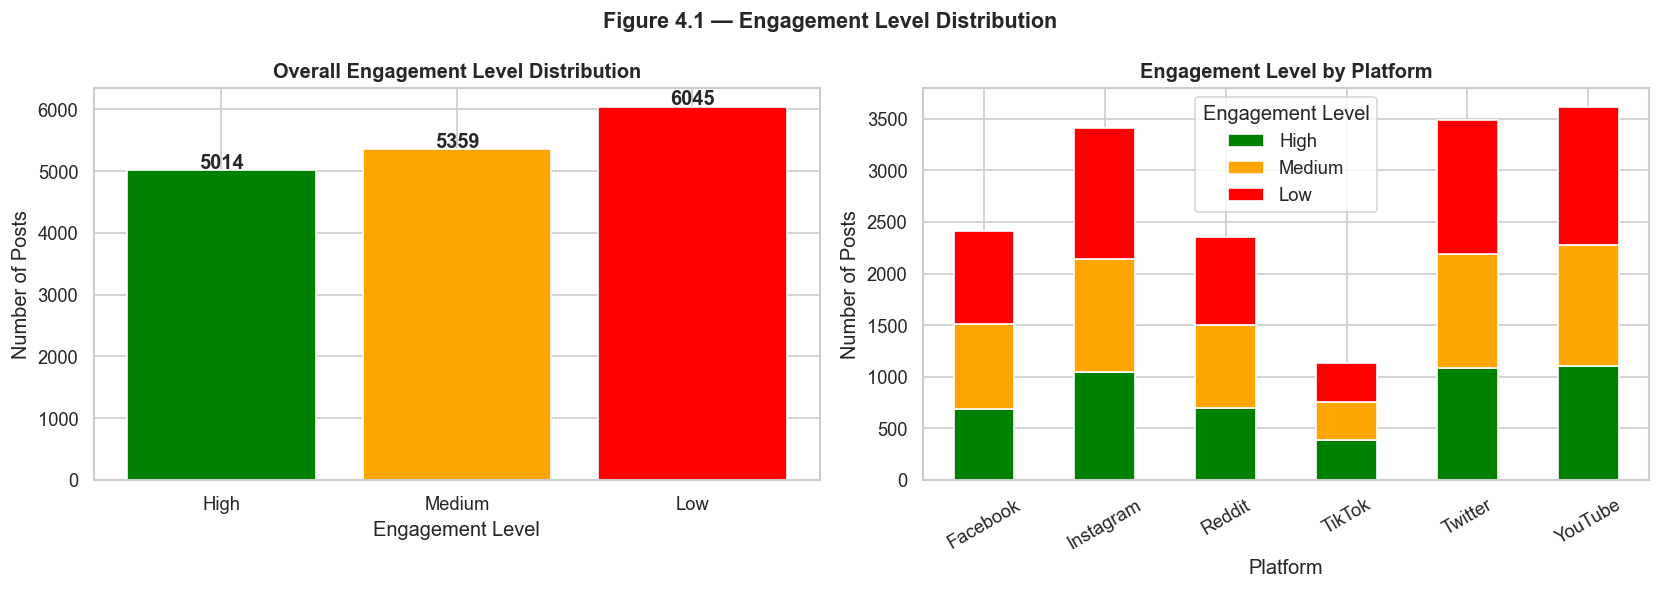


Figure 4.2


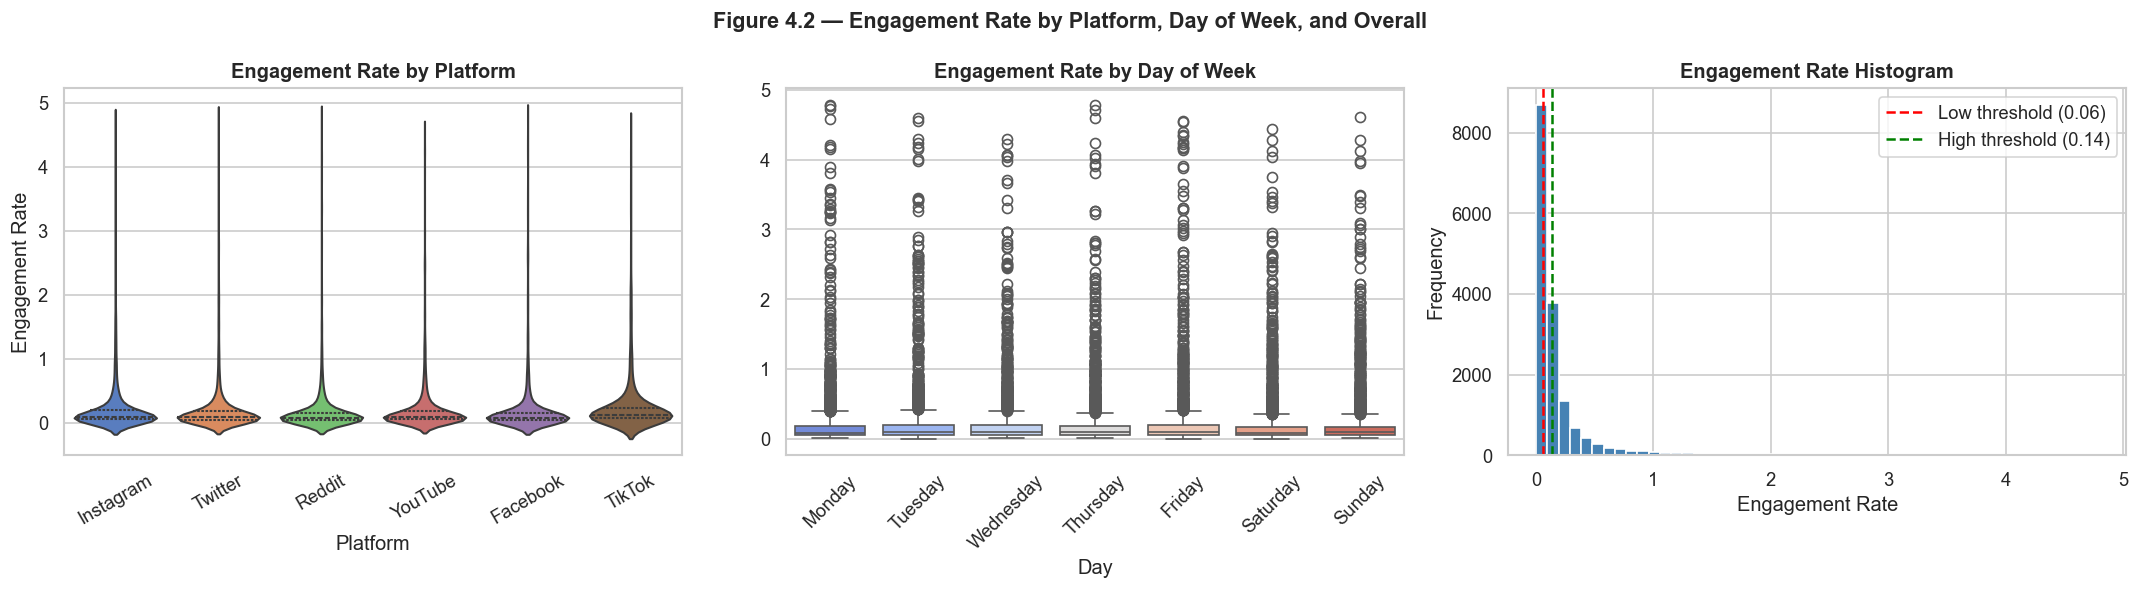


Figure 4.3


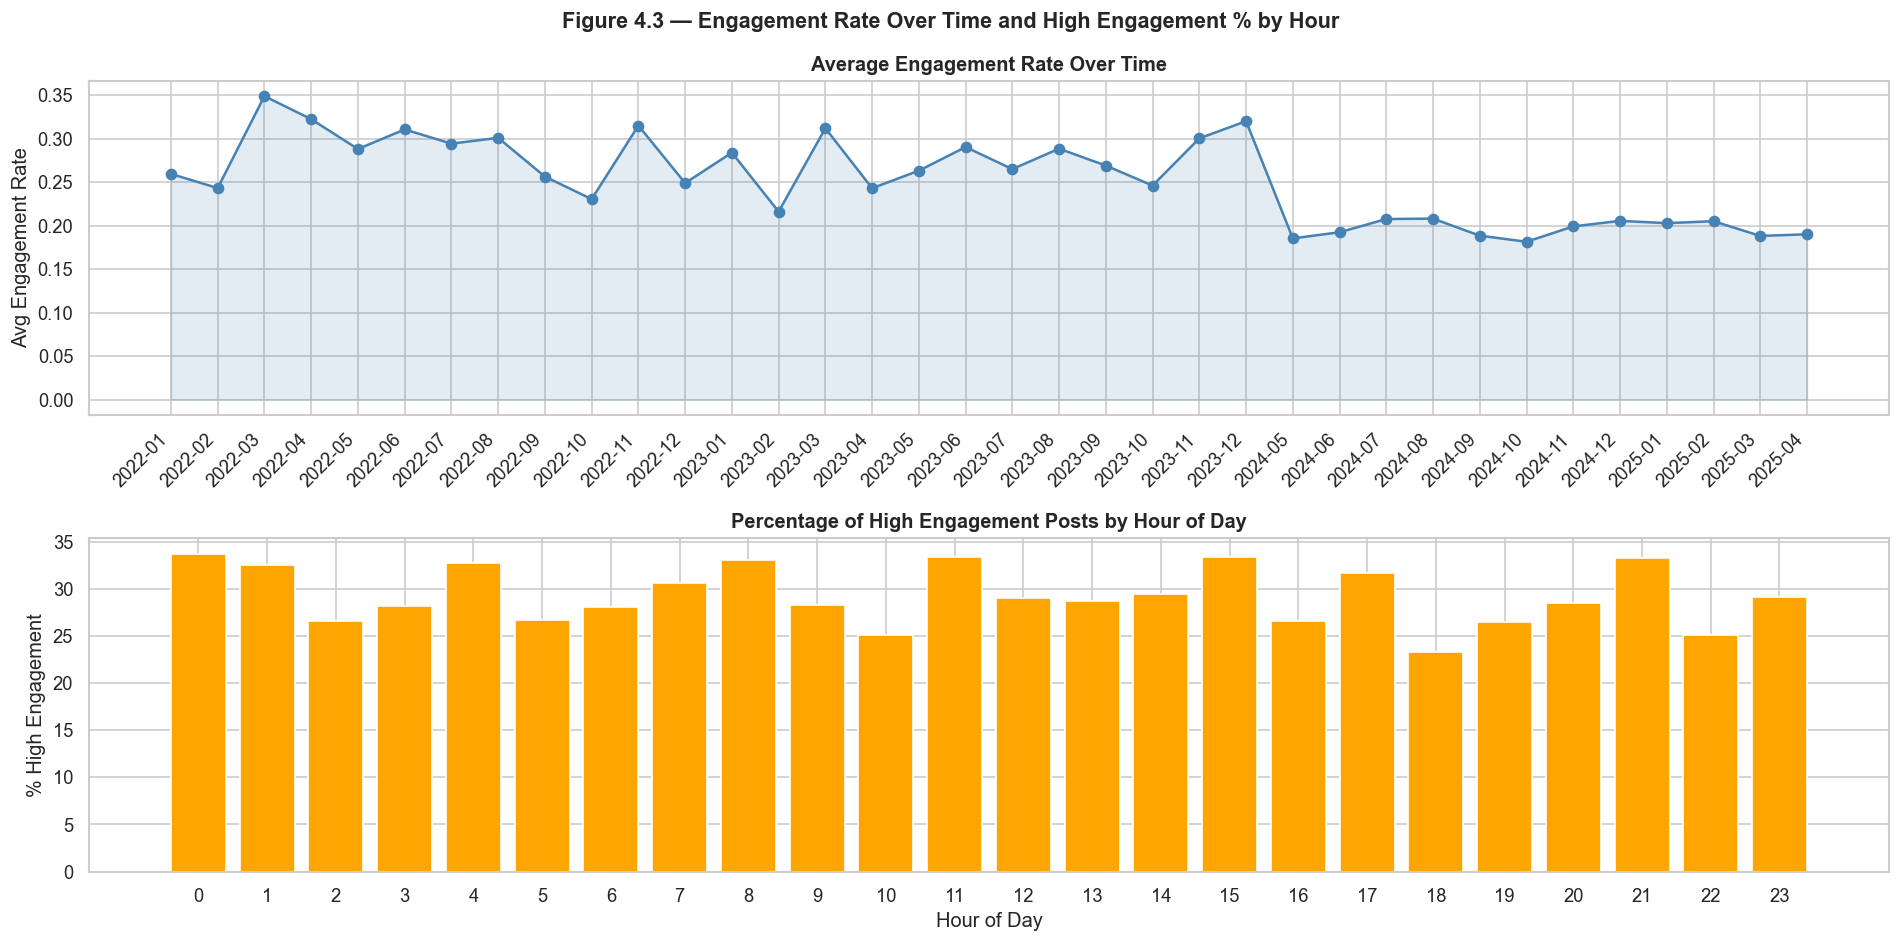


Figure 4.4


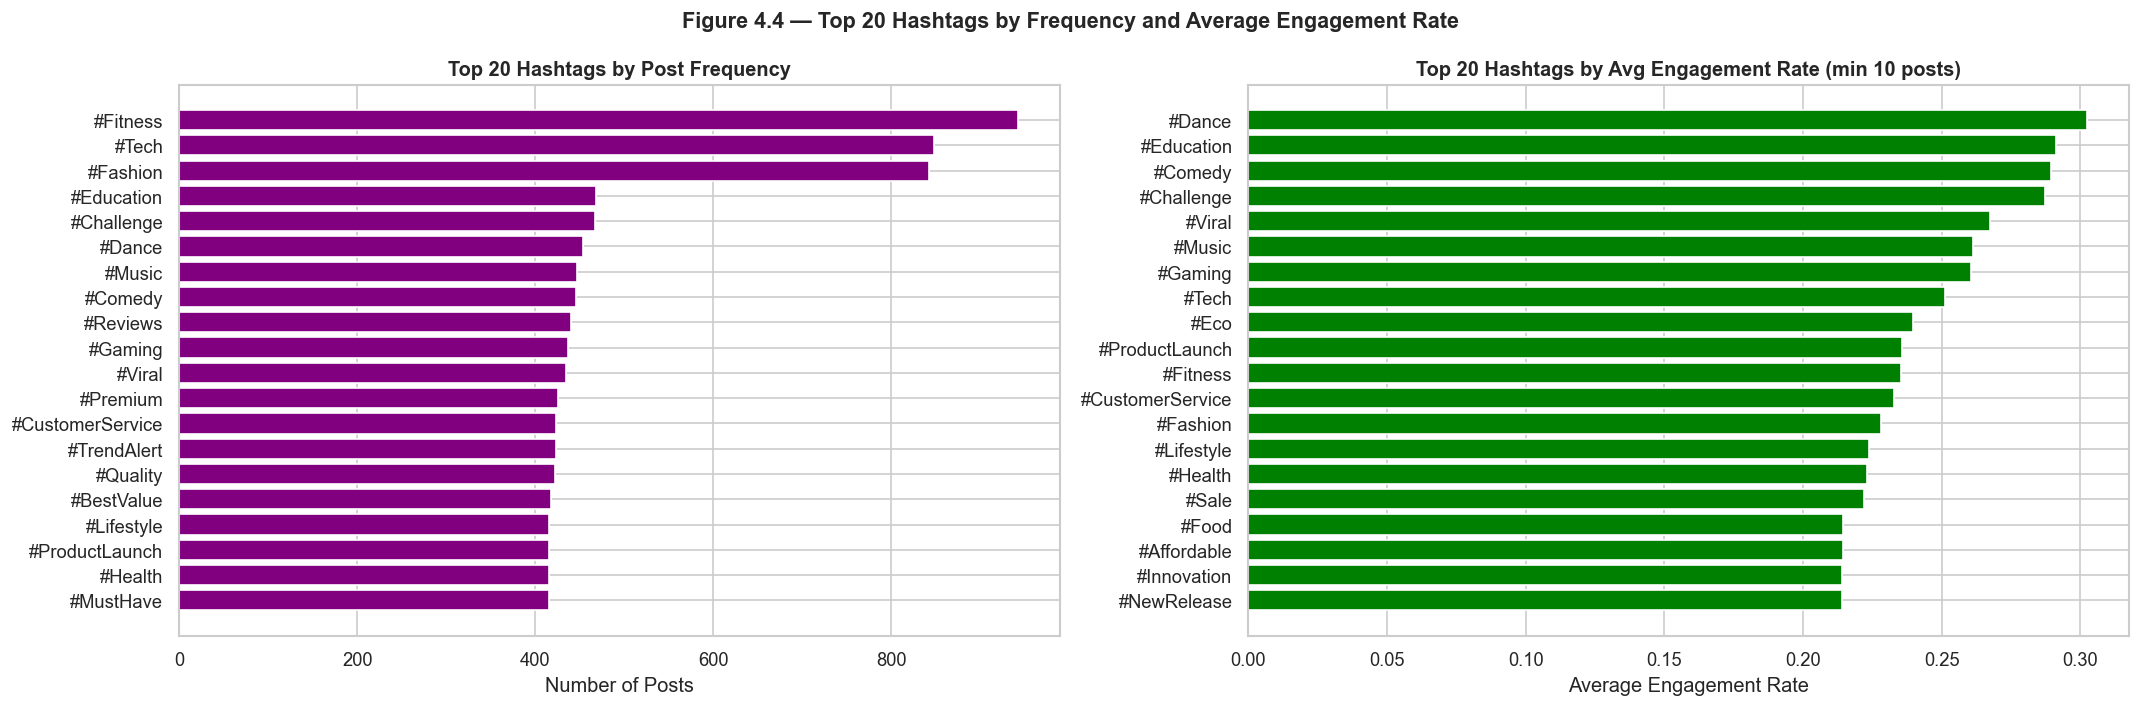


Figure 4.5


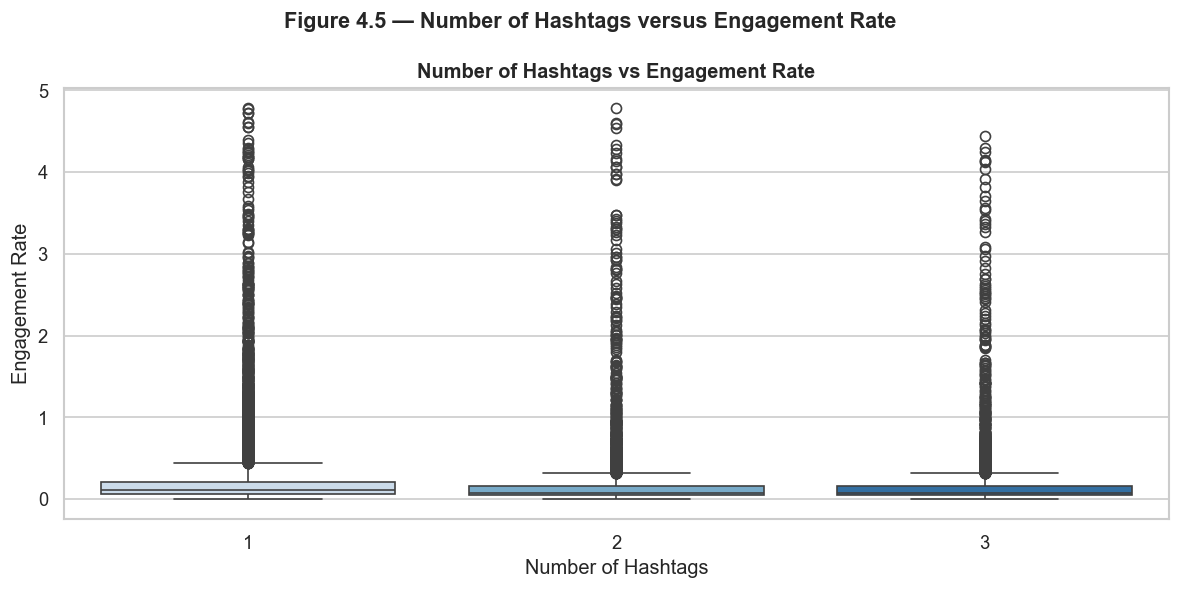


Figure 4.6


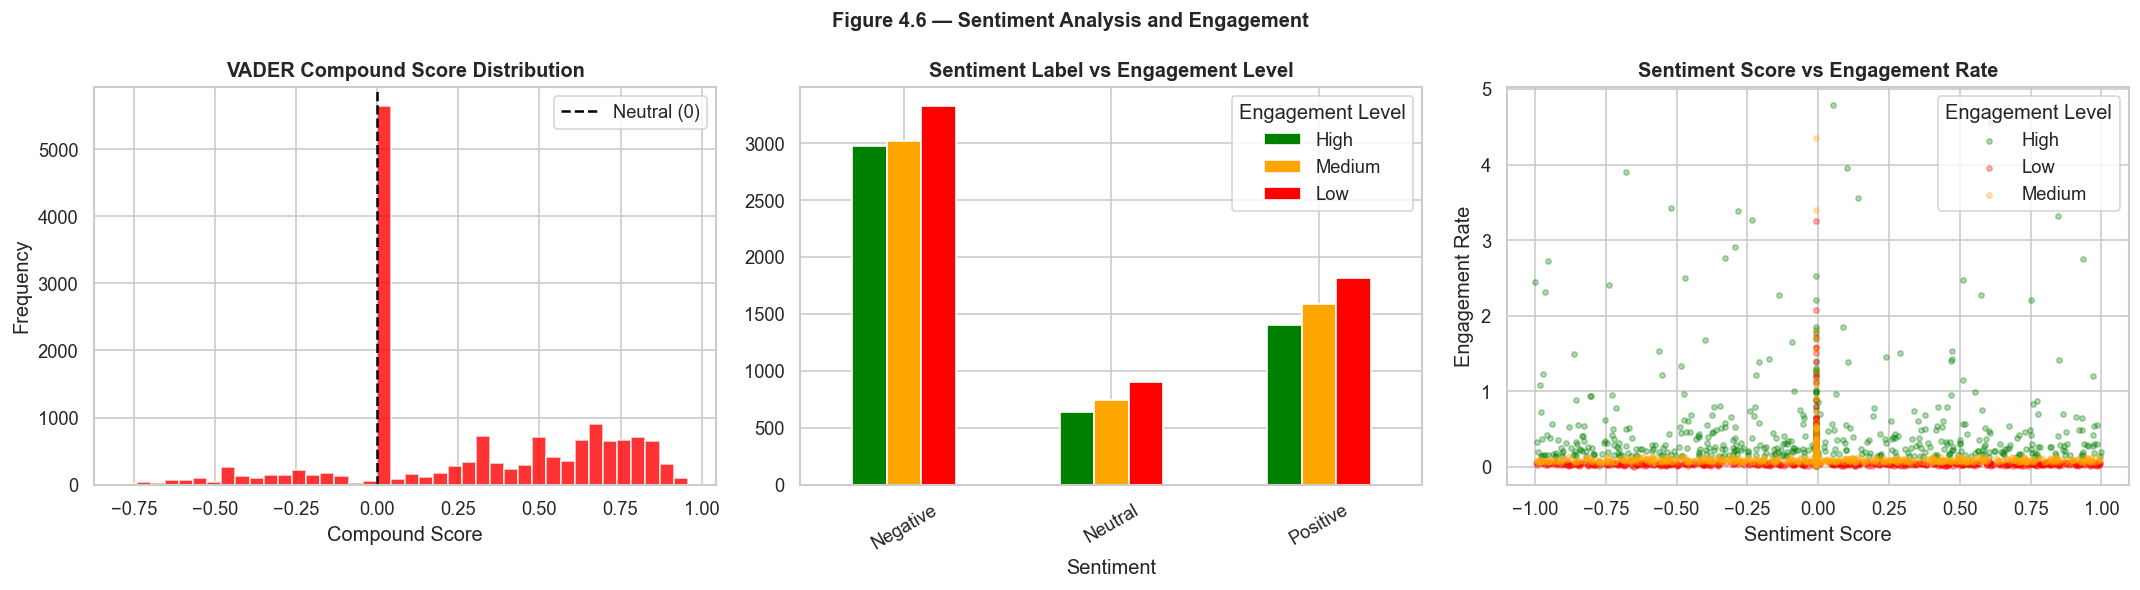


Figure 4.7


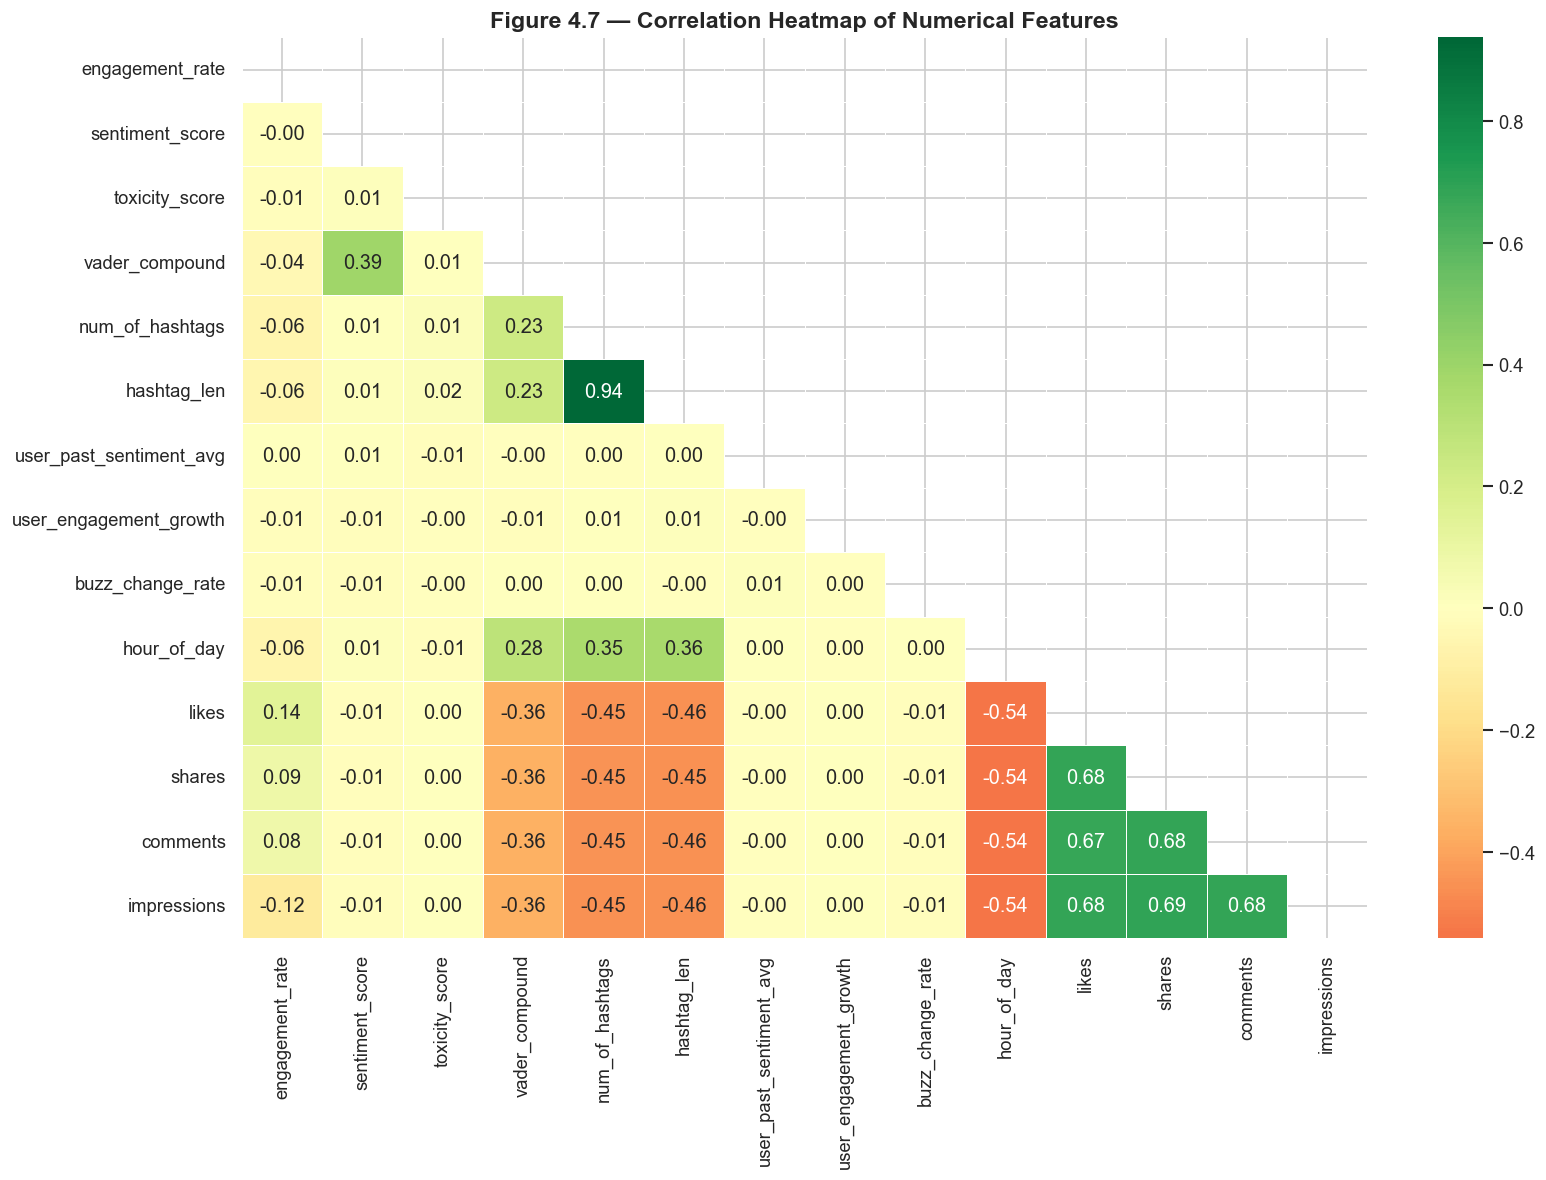

~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [11]:
print("~" * 27)
print("EDA — Visualisation")
print("~" * 27)

# 1. Engagement level distribution
print("\nFigure 4.1")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — overall counts
levels = ["High", "Medium", "Low"]
colors = ["green", "orange", "red"]
counts = df["Engagement_Level"].value_counts().reindex(levels)

axes[0].bar(levels, counts.values, color=colors)
axes[0].set_title("Overall Engagement Level Distribution")
axes[0].set_xlabel("Engagement Level")
axes[0].set_ylabel("Number of Posts")

# Add count labels on top of bars
for i, count in enumerate(counts.values):
    axes[0].text(i, count + 30, str(count), ha="center", fontweight="bold")

# Stacked bar - by platform
platform_counts = df.groupby(["platform", "Engagement_Level"]).size().unstack(fill_value=0)
platform_counts = platform_counts.reindex(columns=levels, fill_value=0)
platform_counts.plot(kind="bar", stacked=True, ax=axes[1], color=colors)
axes[1].set_title("Engagement Level by Platform")
axes[1].set_xlabel("Platform")
axes[1].set_ylabel("Number of Posts")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Engagement Level")

fig.suptitle("Figure 4.1 — Engagement Level Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(Other_imp_byproducts, "Figure_4_1_engagement_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# 2. Engagement rate posts
print("\nFigure 4.2")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Violin plot by platform
sns.violinplot(data=df, x="platform", y="engagement_rate", palette="muted", ax=axes[0], inner="quartile")
axes[0].set_title("Engagement Rate by Platform")
axes[0].set_xlabel("Platform")
axes[0].set_ylabel("Engagement Rate")
axes[0].tick_params(axis="x", rotation=30)

# Box plot by day of week
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_df = df[df["day_of_week"].isin(days)]
sns.boxplot(data=day_df, x="day_of_week", y="engagement_rate", order=days, palette="coolwarm", ax=axes[1])
axes[1].set_title("Engagement Rate by Day of Week")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=45)

# Histogram with thresholds
axes[2].hist(df["engagement_rate"], bins=50, color="steelblue", edgecolor="white")
axes[2].axvline(low_thresh,  color="red",   linestyle="--", label=f"Low threshold ({low_thresh:.2f})")
axes[2].axvline(high_thresh, color="green", linestyle="--", label=f"High threshold ({high_thresh:.2f})")
axes[2].set_title("Engagement Rate Histogram")
axes[2].set_xlabel("Engagement Rate")
axes[2].set_ylabel("Frequency")
axes[2].legend()

fig.suptitle("Figure 4.2 — Engagement Rate by Platform, Day of Week, and Overall", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(Other_imp_byproducts, "Figure_4_2_engagement_rate_plots.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# 3. Time Series
print("\nFigure 4.3")

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Average engagement rate over time
df["month_year"] = df["timestamp"].dt.to_period("M")
monthly = df.groupby("month_year")["engagement_rate"].mean().reset_index()
monthly["month_year"] = monthly["month_year"].astype(str)

axes[0].plot(monthly["month_year"], monthly["engagement_rate"], marker="o", color="steelblue")
axes[0].fill_between(range(len(monthly)), monthly["engagement_rate"], alpha=0.15, color="steelblue")
axes[0].set_title("Average Engagement Rate Over Time")
axes[0].set_ylabel("Avg Engagement Rate")
axes[0].set_xticks(range(len(monthly)))
axes[0].set_xticklabels(monthly["month_year"], rotation=45, ha="right")

# High engagement % by hour
hour_high = df.groupby("hour_of_day")["Engagement_Level"].apply(
    lambda x: (x == "High").mean() * 100
).reset_index()
hour_high.columns = ["hour", "high_pct"]

axes[1].bar(hour_high["hour"], hour_high["high_pct"], color="orange", edgecolor="white")
axes[1].set_title("Percentage of High Engagement Posts by Hour of Day")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("% High Engagement")
axes[1].set_xticks(range(24))

fig.suptitle("Figure 4.3 — Engagement Rate Over Time and High Engagement % by Hour", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(Other_imp_byproducts, "Figure_4_3_time_series.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# 4. Top 20 hashtags
print("\nFigure 4.4")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top 20 by frequency
top_freq = df["primary_hashtag"].value_counts().head(20)
axes[0].barh(top_freq.index[::-1], top_freq.values[::-1], color="purple")
axes[0].set_title("Top 20 Hashtags by Post Frequency")
axes[0].set_xlabel("Number of Posts")

# Top 20 by average engagement rate (min 10 posts)
hashtag_stats = df.groupby("primary_hashtag")["engagement_rate"].agg(["mean", "count"])
hashtag_stats = hashtag_stats[hashtag_stats["count"] >= 10]
top_eng = hashtag_stats.sort_values("mean", ascending=False).head(20)
axes[1].barh(top_eng.index[::-1], top_eng["mean"].values[::-1], color="green")
axes[1].set_title("Top 20 Hashtags by Avg Engagement Rate (min 10 posts)")
axes[1].set_xlabel("Average Engagement Rate")

fig.suptitle("Figure 4.4 — Top 20 Hashtags by Frequency and Average Engagement Rate", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(Other_imp_byproducts, "Figure_4_4_hashtags.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# 5. No.of hashtags vs engagement rate
print("\nFigure 4.5")

fig, ax = plt.subplots(figsize=(10, 5))

# Only show posts with 8 or fewer hashtags to avoid outliers
hashtag_df = df[df["num_of_hashtags"] <= 8]
sns.boxplot(data=hashtag_df, x="num_of_hashtags", y="engagement_rate", palette="Blues", ax=ax)
ax.set_title("Number of Hashtags vs Engagement Rate")
ax.set_xlabel("Number of Hashtags")
ax.set_ylabel("Engagement Rate")

fig.suptitle("Figure 4.5 — Number of Hashtags versus Engagement Rate", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(Other_imp_byproducts, "Figure_4_5_hashtag_count.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# 6. Sentiment analysis
print("\nFigure 4.6")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# VADER compound score histogram
axes[0].hist(df["vader_compound"], bins=40, color="red", edgecolor="white", alpha=0.8)
axes[0].axvline(0, color="black", linestyle="--", label="Neutral (0)")
axes[0].set_title("VADER Compound Score Distribution")
axes[0].set_xlabel("Compound Score")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Sentiment label vs engagement level - grouped bar
sent_counts = df.groupby(["sentiment_label", "Engagement_Level"]).size().unstack(fill_value=0)
sent_counts = sent_counts.reindex(columns=["High", "Medium", "Low"], fill_value=0)
sent_counts.plot(kind="bar", ax=axes[1], color=["green", "orange", "red"], edgecolor="white")
axes[1].set_title("Sentiment Label vs Engagement Level")
axes[1].set_xlabel("Sentiment")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Engagement Level")

# Sentiment score vs engagement rate - scatter plot
sample = df.sample(min(2000, len(df)), random_state=42)
level_colors = {"High": "green", "Medium": "orange", "Low": "red"}
for level, group in sample.groupby("Engagement_Level"):
    axes[2].scatter(
        group["sentiment_score"],
        group["engagement_rate"],
        alpha=0.3, s=10,
        label=level,
        color=level_colors[level]
    )
axes[2].set_title("Sentiment Score vs Engagement Rate")
axes[2].set_xlabel("Sentiment Score")
axes[2].set_ylabel("Engagement Rate")
axes[2].legend(title="Engagement Level")

fig.suptitle("Figure 4.6 — Sentiment Analysis and Engagement", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(Other_imp_byproducts, "Figure_4_6_sentiment.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# 7. Correlation heatmap
print("\nFigure 4.7")

# Select only numerical columns that exist in df
num_cols = ["engagement_rate", "sentiment_score", "toxicity_score", "vader_compound",
            "num_of_hashtags", "hashtag_len", "user_past_sentiment_avg",
            "user_engagement_growth", "buzz_change_rate", "hour_of_day",
            "likes", "shares", "comments", "impressions"]
num_cols = [c for c in num_cols if c in df.columns]

corr_matrix = df[num_cols].corr()

# Only show lower triangle - mask upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    mask    = mask,
    annot   = True,
    fmt     = ".2f",
    cmap    = "RdYlGn",
    center  = 0,
    ax      = ax,
    linewidths = 0.5
)
ax.set_title("Figure 4.7 — Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(Other_imp_byproducts, "Figure_4_7_correlation.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("~" * 27)

## Feature Engineering & Preprocessor

In [12]:
print("~" * 27)

cat_cols = ["platform","day_of_week","primary_hashtag","topic_category","sentiment_label",
            "emotion_type","campaign_phase","campaign_name","brand_name","content_type","region"]
num_cols = ["hour_of_day","num_of_hashtags","hashtag_len","sentiment_score","toxicity_score",
            "vader_compound","user_past_sentiment_avg","user_engagement_growth","buzz_change_rate"]
target_var = "Engagement_Level"

cat_cols = [c for c in cat_cols if c in df.columns]
num_cols = [c for c in num_cols if c in df.columns]

lab_enc = LabelEncoder()
df["target_encoded"] = lab_enc.fit_transform(df[target_var])

X = df[cat_cols + num_cols].copy()
y = df["target_encoded"].values
for c in cat_cols: X[c] = X[c].astype(str)

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])

X_train_raw = X.loc[train_idx]
X_test_raw = X.loc[test_idx]
y_train = y[train_idx]
y_test  = y[test_idx]
X_train = preprocessor.fit_transform(X_train_raw)
X_test  = preprocessor.transform(X_test_raw)
feat_names = list(preprocessor.get_feature_names_out())

print(f"Categorical features ({len(cat_cols)}): {cat_cols}")
print(f"\nNumerical  features ({len(num_cols)}): {num_cols}")
print(f"\nLabel encoding : {dict(zip(lab_enc.classes_, lab_enc.transform(lab_enc.classes_)))}")
print(f"\nX_train shape  : {X_train.shape}")
print(f"\nX_test  shape  : {X_test.shape}")
print(f"\nTotal features : {len(feat_names)}")
print("~" * 27)

~~~~~~~~~~~~~~~~~~~~~~~~~~~
Categorical features (11): ['platform', 'day_of_week', 'primary_hashtag', 'topic_category', 'sentiment_label', 'emotion_type', 'campaign_phase', 'campaign_name', 'brand_name', 'content_type', 'region']

Numerical  features (9): ['hour_of_day', 'num_of_hashtags', 'hashtag_len', 'sentiment_score', 'toxicity_score', 'vader_compound', 'user_past_sentiment_avg', 'user_engagement_growth', 'buzz_change_rate']

Label encoding : {'High': 0, 'Low': 1, 'Medium': 2}

X_train shape  : (13134, 125)

X_test  shape  : (3284, 125)

Total features : 125
~~~~~~~~~~~~~~~~~~~~~~~~~~~


~~~~~~~~~~~~~~~~~~~~~~~~~~~
LEARNING CURVES — Bias / Variance Diagnosis
~~~~~~~~~~~~~~~~~~~~~~~~~~~


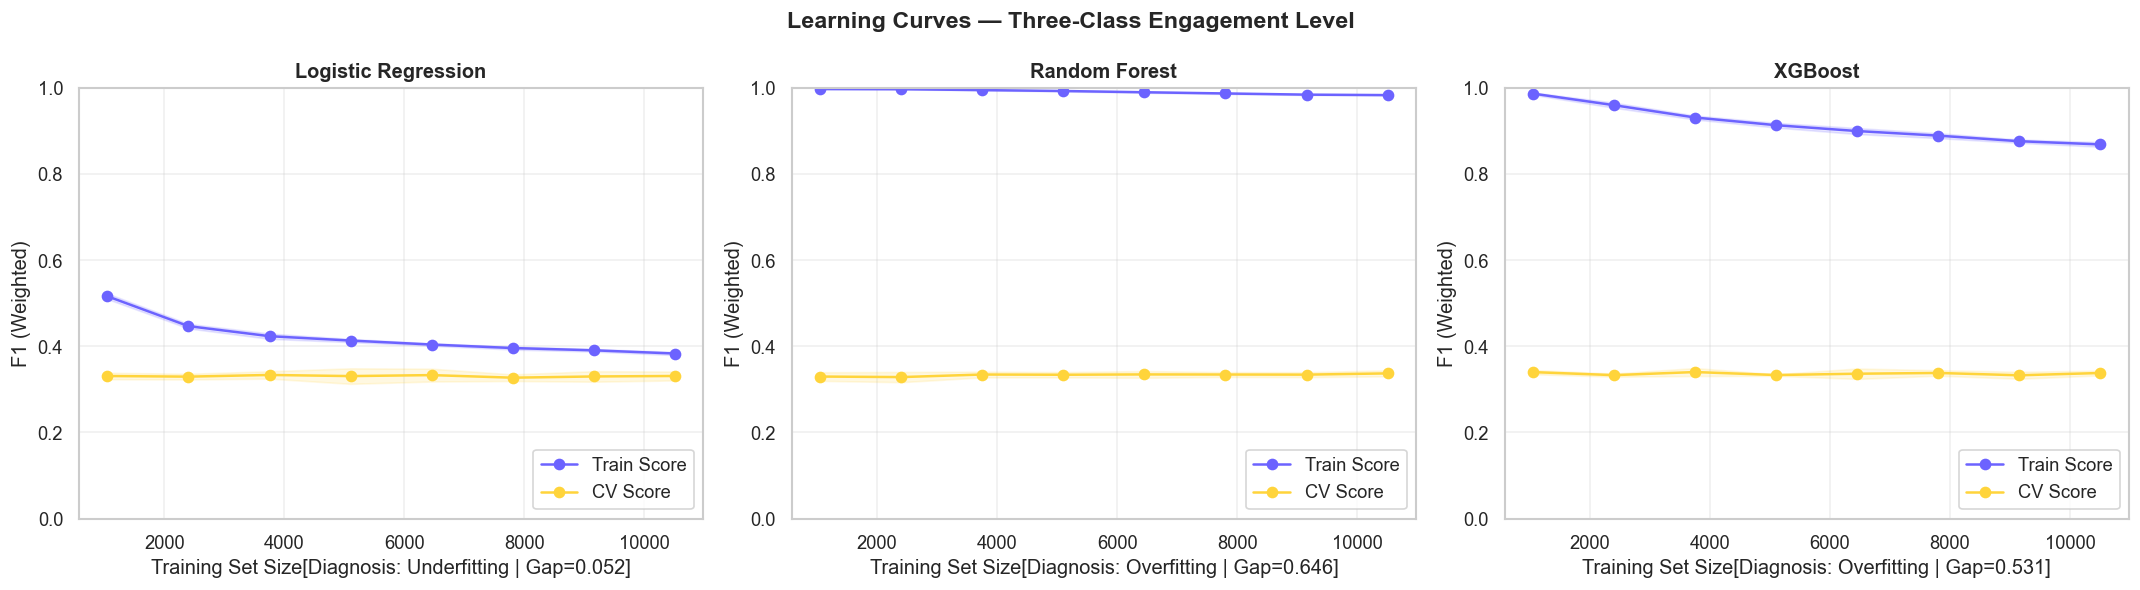

Diagnosis Summary:
----------------------------------------
Logistic Regression       Train F1=0.3832  CV F1=0.3310  Gap=0.0522  -> UNDERFITTING
Random Forest             Train F1=0.9834  CV F1=0.3370  Gap=0.6463  -> OVERFITTING
XGBoost                   Train F1=0.8688  CV F1=0.3379  Gap=0.5309  -> OVERFITTING
----------------------------------------
~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [13]:
print(f"{'~'*27}")
print("LEARNING CURVES — Bias / Variance Diagnosis")
print(f"{'~'*27}")

from sklearn.model_selection import learning_curve

train_sizes = np.linspace(0.1, 1.0, 8)

lc_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced"),
    "XGBoost":             XGBClassifier(n_estimators=100, random_state=42, eval_metric="mlogloss", use_label_encoder=False),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Learning Curves — Three-Class Engagement Level", fontsize=14, fontweight="bold")

for ax, (name, clf) in zip(axes, lc_models.items()):
    tr_sizes, tr_scores, cv_scores = learning_curve(
        clf, X_train, y_train,
        train_sizes=train_sizes,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring="f1_weighted",
        n_jobs=-1,
    )
    tr_mean = tr_scores.mean(axis=1)
    tr_std  = tr_scores.std(axis=1)
    cv_mean = cv_scores.mean(axis=1)
    cv_std  = cv_scores.std(axis=1)

    ax.plot(tr_sizes, tr_mean, "o-", color="#6c63ff", label="Train Score")
    ax.fill_between(tr_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color="#6c63ff")
    ax.plot(tr_sizes, cv_mean, "o-", color="#FFD43B", label="CV Score")
    ax.fill_between(tr_sizes, cv_mean - cv_std, cv_mean + cv_std, alpha=0.15, color="#FFD43B")
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Training Set Size")
    ax.set_ylabel("F1 (Weighted)")
    ax.set_ylim(0, 1)
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)

    gap = abs(tr_mean[-1] - cv_mean[-1])
    diagnosis = "Overfitting" if gap > 0.1 else "Underfitting" if cv_mean[-1] < 0.5 else "Good Fit"
    ax.set_xlabel(f"Training Set Size[Diagnosis: {diagnosis} | Gap={gap:.3f}]")

plt.tight_layout()
plt.savefig(os.path.join(Other_imp_byproducts, "learning_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Diagnosis Summary:")
print("-" * 40)
for name, clf in lc_models.items():
    tr_sizes, tr_scores, cv_scores = learning_curve(
        clf, X_train, y_train,
        train_sizes=[1.0],
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring="f1_weighted",
        n_jobs=-1,
    )
    tr_f1 = tr_scores.mean()
    cv_f1 = cv_scores.mean()
    gap   = abs(tr_f1 - cv_f1)
    diag  = "OVERFITTING" if gap > 0.1 else "UNDERFITTING" if cv_f1 < 0.5 else "GOOD FIT"
    print(f"{name:<25} Train F1={tr_f1:.4f}  CV F1={cv_f1:.4f}  Gap={gap:.4f}  -> {diag}")
print("-" * 40)
print(f"{'~'*27}")


## Build Models & Models Comparison

### Three Class Classification

## Overfitting Diagnosis — Learning Curve Findings

Learning curves revealed that **Random Forest** (train-CV gap=0.65) and **XGBoost** (gap=0.53) are severely overfitting on the three-class task — both achieve near-perfect training F1 (~0.98 and ~0.87) but CV F1 collapses to ~0.33 (near random chance). **Logistic Regression** underfits with both scores low and close together.

Key insight: the CV scores are flat regardless of training size for all models, meaning additional data does not help. The root cause is the **thin class boundaries** produced by equal-percentile splits on synthetic data — adjacent classes (Low/Medium, Medium/High) are not separable from pre-post features alone. This directly motivates the **extreme binary formulation**, which removes the ambiguous middle 50% and produces cleaner class boundaries, resulting in a meaningful CV AUC of ~0.61 vs ~0.33 here.

In [14]:
# print(f"{'~'*27}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced"),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, eval_metric="mlogloss", use_label_encoder=False),
}

# Cross validation
print(f"\n{'~'*27}")
print(f"5-FOLD CROSS-VALIDATION RESULTS")
print(f"{'-'*27}")
cv_results = []
for name, clf in classifiers.items():
    acc = cross_val_score(clf, X_train, y_train, cv=cv, scoring="accuracy")
    f1  = cross_val_score(clf, X_train, y_train, cv=cv, scoring="f1_weighted")
    rec = cross_val_score(clf, X_train, y_train, cv=cv, scoring="recall_weighted")
    cv_results.append({"Model":name,
                       "CV Accuracy": f"{acc.mean():.4f} +/- {acc.std():.4f}",
                       "CV F1": f"{f1.mean():.4f} +/- {f1.std():.4f}",
                       "CV Recall": f"{rec.mean():.4f} +/- {rec.std():.4f}"})
    print(f"{name:<25} Acc={acc.mean():.4f}+/-{acc.std():.4f}  F1={f1.mean():.4f}  Rec={rec.mean():.4f}")
print("-" * 27)

# Fit & test
print(f"\n{'~'*27}")
print(f"TEST SET CLASSIFICATION REPORTS")
print(f"{'-'*27}")
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(f"\n── {name} ──")
    print(f"Accuracy : {accuracy_score(y_test,y_pred):.4f}  |  "
          f"F1 (weighted) : {f1_score(y_test,y_pred,average='weighted'):.4f}  |  "
          f"Recall : {recall_score(y_test,y_pred,average='weighted'):.4f}")
    print(classification_report(y_test, y_pred, target_names=lab_enc.classes_, digits=4))
print(f"{'-'*27}")

# Tuning XGBoost with GridSearchCV
print(f"\n{'~'*27}")
print(f"XGBOOST GRIDSEARCHCV — TUNING")
print(f"{'-'*27}")
param_grid = {"n_estimators":[100,200],
              "max_depth":[3,5],
              "learning_rate":[0.05,0.1],
              "subsample":[0.8,1.0]}
grid_clf = GridSearchCV(XGBClassifier(random_state=42, eval_metric="mlogloss", use_label_encoder=False),
                          param_grid, cv=3, scoring="f1_weighted", n_jobs=-1, verbose=1)
grid_clf.fit(X_train, y_train)
best_xgb_clf = grid_clf.best_estimator_
y_pred_best  = best_xgb_clf.predict(X_test)
print(f"\nBest Parameters : {grid_clf.best_params_}")
print(f"Best CV F1 : {grid_clf.best_score_:.4f}")
print(f"\n── XGBoost Tuned — Test Set ──")
print(f"Accuracy : {accuracy_score(y_test,y_pred_best):.4f}  |  "
      f"F1 : {f1_score(y_test,y_pred_best,average='weighted'):.4f}  |  "
      f"Recall : {recall_score(y_test,y_pred_best,average='weighted'):.4f}")
print(classification_report(y_test, y_pred_best, target_names=lab_enc.classes_, digits=4))
print(f"{'-'*27}")

# Model comparison
comparison_rows = []
for name, clf in classifiers.items():
    y_pred = clf.predict(X_test)
    comparison_rows.append({"Model":name,
                             "Accuracy": round(accuracy_score(y_test,y_pred),4),
                             "F1 weighted": round(f1_score(y_test,y_pred,average="weighted"),4),
                             "Recall weighted": round(recall_score(y_test,y_pred,average="weighted"),4)})
comparison_rows.append({"Model":"XGBoost Tuned",
                         "Accuracy": round(accuracy_score(y_test,y_pred_best),4),
                         "F1 weighted": round(f1_score(y_test,y_pred_best,average="weighted"),4),
                         "Recall weighted": round(recall_score(y_test,y_pred_best,average="weighted"),4)})
compdf = pd.DataFrame(comparison_rows)
print(f"\n{'~'*27}")
print(f"THREE-CLASS MODEL COMPARISON TABLE")
print(f"{'-'*27}")
print(compdf.to_string(index=False))
print(f"{'-'*27}")
compdf.to_csv(os.path.join(Other_imp_byproducts,"model_comparison_results.csv"), index=False)

# Baseline comparison
dummy_zeror = DummyClassifier(strategy="most_frequent", random_state=42)
dummy_zeror.fit(X_train, y_train)
dummy_strat = DummyClassifier(strategy="stratified", random_state=42)
dummy_strat.fit(X_train, y_train)

acc_zeror = accuracy_score(y_test, dummy_zeror.predict(X_test))
f1_zeror  = f1_score(y_test, dummy_zeror.predict(X_test), average="weighted", zero_division=0)
acc_strat = accuracy_score(y_test, dummy_strat.predict(X_test))
f1_strat  = f1_score(y_test, dummy_strat.predict(X_test), average="weighted", zero_division=0)

baseline_rows = [
    {"Model":"ZeroR (Most Frequent)", "Accuracy":round(acc_zeror,4), "F1 weighted":round(f1_zeror,4), "Type":"Baseline"},
    {"Model":"Stratified Random", "Accuracy":round(acc_strat,4), "F1 weighted":round(f1_strat,4), "Type":"Baseline"},
]
model_rows_aug = []
for name, clf in classifiers.items():
    y_pred = clf.predict(X_test)
    model_rows_aug.append({"Model":name,
                            "Accuracy": round(accuracy_score(y_test,y_pred),4),
                            "F1 weighted": round(f1_score(y_test,y_pred,average="weighted"),4),
                            "Type":"Model"})
model_rows_aug.append({"Model":"XGBoost (Tuned)",
                        "Accuracy": round(accuracy_score(y_test,y_pred_best),4),
                        "F1 weighted": round(f1_score(y_test,y_pred_best,average="weighted"),4),
                        "Type":"Model"})
aug_df = pd.DataFrame(baseline_rows + model_rows_aug)

print(f"{'~'*27}")
print(f"BASELINES vs ML MODELS")
print(f"{'-'*27}")
print(aug_df[["Model","Accuracy","F1 weighted","Type"]].to_string(index=False))
print(f"\nKEY INSIGHT:")
print(f"ZeroR accuracy ({acc_zeror:.4f}) ≈ best 3-class ML model")
print(f"Thin class boundaries from percentile-split labels on synthetic data.")
print(f"Extreme Binary experiment (top/bottom 25%) is the stronger result.")
print(f"{'-'*27}")
print(f"{'~'*27}")


~~~~~~~~~~~~~~~~~~~~~~~~~~~
5-FOLD CROSS-VALIDATION RESULTS
---------------------------
Logistic Regression       Acc=0.3319+/-0.0105  F1=0.3310  Rec=0.3319
Random Forest             Acc=0.3502+/-0.0075  F1=0.3377  Rec=0.3502
XGBoost                   Acc=0.3404+/-0.0070  F1=0.3361  Rec=0.3404
---------------------------

~~~~~~~~~~~~~~~~~~~~~~~~~~~
TEST SET CLASSIFICATION REPORTS
---------------------------

── Logistic Regression ──
Accuracy : 0.3362  |  F1 (weighted) : 0.3355  |  Recall : 0.3362
              precision    recall  f1-score   support

        High     0.3021    0.4020    0.3450       980
         Low     0.3628    0.3151    0.3373      1171
      Medium     0.3541    0.3010    0.3254      1133

    accuracy                         0.3362      3284
   macro avg     0.3397    0.3394    0.3359      3284
weighted avg     0.3417    0.3362    0.3355      3284


── Random Forest ──
Accuracy : 0.3581  |  F1 (weighted) : 0.3439  |  Recall : 0.3581
              precision    r

## Regression - Engagement Rate Prediction

In [15]:
print(f"{'~'*27}")

y_reg_all = df["engagement_rate"].values
y_reg_train = y_reg_all[train_idx]
y_reg_test = y_reg_all[test_idx]
kf = KFold(n_splits=5, shuffle=True, random_state=42)

regressors = {
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost Regressor": XGBRegressor(n_estimators=100, random_state=42, eval_metric="rmse"),
}

print(f"\n{'~'*27}")
print(f"5-FOLD CV RESULTS")
print(f"{'~'*27}")
for name, reg in regressors.items():
    rmse_cv = np.sqrt(-cross_val_score(reg, X_train, y_reg_train, cv=kf, scoring="neg_mean_squared_error"))
    r2_cv = cross_val_score(reg, X_train, y_reg_train, cv=kf, scoring="r2")
    print(f"{name:<30} RMSE={rmse_cv.mean():.4f}+/-{rmse_cv.std():.4f}  R²={r2_cv.mean():.4f}+/-{r2_cv.std():.4f}")

for name, reg in regressors.items():
    reg.fit(X_train, y_reg_train)

print(f"\n{'~'*27}")
print(f"TEST SET RESULTS")
print(f"{'~'*27}")
for name, reg in regressors.items():
    y_pred_r = reg.predict(X_test)
    print(f"{name:<30} RMSE={np.sqrt(mean_squared_error(y_reg_test,y_pred_r)):.4f}  "
          f"MAE={mean_absolute_error(y_reg_test,y_pred_r):.4f}  "
          f"R²={r2_score(y_reg_test,y_pred_r):.4f}")

print(f"\nRunning GridSearchCV on Random Forest Regressor")
rf_param_grid = {"n_estimators":[100,200],"max_depth":[None,10,20],"min_samples_split":[2,5]}
grid_reg = GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid,
                        cv=3, scoring="neg_mean_squared_error", n_jobs=-1, verbose=1)
grid_reg.fit(X_train, y_reg_train)
best_rf_reg = grid_reg.best_estimator_
y_pred_rf_best = best_rf_reg.predict(X_test)
print(f"\nBest RF Reg Params: {grid_reg.best_params_}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_reg_test,y_pred_rf_best)):.4f}  "
      f"MAE: {mean_absolute_error(y_reg_test,y_pred_rf_best):.4f}  "
      f"R²: {r2_score(y_reg_test,y_pred_rf_best):.4f}")
print(f"{'~'*27}")

~~~~~~~~~~~~~~~~~~~~~~~~~~~

~~~~~~~~~~~~~~~~~~~~~~~~~~~
5-FOLD CV RESULTS
~~~~~~~~~~~~~~~~~~~~~~~~~~~
Random Forest Regressor        RMSE=0.4609+/-0.0225  R²=-0.1019+/-0.0291
XGBoost Regressor              RMSE=0.4721+/-0.0235  R²=-0.1561+/-0.0264

~~~~~~~~~~~~~~~~~~~~~~~~~~~
TEST SET RESULTS
~~~~~~~~~~~~~~~~~~~~~~~~~~~
Random Forest Regressor        RMSE=0.4435  MAE=0.2303  R²=-0.0844
XGBoost Regressor              RMSE=0.4604  MAE=0.2336  R²=-0.1685

Running GridSearchCV on Random Forest Regressor
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best RF Reg Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
RMSE: 0.4293  MAE: 0.2121  R²: -0.0159
~~~~~~~~~~~~~~~~~~~~~~~~~~~


## Binary Classification - High vs Not High

In [16]:
print(f"{'~'*27}")
df_bin = df.copy()
df_bin["is_high"] = (df_bin["Engagement_Level"] == "High").astype(int)
train_bin_idx, test_bin_idx = train_test_split(df_bin.index, test_size=0.2, random_state=42, stratify=df_bin["is_high"])

X_bin = df_bin[cat_cols + num_cols].copy()
for c in cat_cols: X_bin[c] = X_bin[c].astype(str)
y_bin = df_bin["is_high"].values

preprocessor_bin = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])
X_bin_train = preprocessor_bin.fit_transform(X_bin.loc[train_bin_idx])
X_bin_test  = preprocessor_bin.transform(X_bin.loc[test_bin_idx])
y_bin_train = y_bin[df_bin.index.get_indexer(train_bin_idx)]
y_bin_test  = y_bin[df_bin.index.get_indexer(test_bin_idx)]

binary_classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced"),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss", use_label_encoder=False),
}

print(f"\n{'~'*27}")
print(f"BINARY — TEST SET RESULTS")
print(f"{'~'*27}")
roc_data_bin = {}
binary_results = []
for name, clf in binary_classifiers.items():
    clf.fit(X_bin_train, y_bin_train)
    y_pred = clf.predict(X_bin_test)
    y_prob = clf.predict_proba(X_bin_test)[:,1]
    fpr_b, tpr_b, _ = roc_curve(y_bin_test, y_prob)
    roc_auc_b = auc(fpr_b, tpr_b)
    roc_data_bin[name] = (fpr_b, tpr_b, roc_auc_b)
    binary_results.append({"Model":name,
                            "Accuracy":round(accuracy_score(y_bin_test,y_pred),4),
                            "F1 weighted":round(f1_score(y_bin_test,y_pred,average="weighted"),4),
                            "AUC":round(roc_auc_b,4)})
    print(f"── {name}")
    print(f"Accuracy={accuracy_score(y_bin_test,y_pred):.4f}  F1={f1_score(y_bin_test,y_pred,average='weighted'):.4f}  AUC={roc_auc_b:.4f}")
    print(classification_report(y_bin_test, y_pred, target_names=["Not High","High"], digits=4))

print(f"{'~'*27}")
print(pd.DataFrame(binary_results).to_string(index=False))
print(f"{'~'*27}")

~~~~~~~~~~~~~~~~~~~~~~~~~~~

~~~~~~~~~~~~~~~~~~~~~~~~~~~
BINARY — TEST SET RESULTS
~~~~~~~~~~~~~~~~~~~~~~~~~~~
── Logistic Regression
Accuracy=0.5167  F1=0.5358  AUC=0.5072
              precision    recall  f1-score   support

    Not High     0.7073    0.5191    0.5987      2281
        High     0.3186    0.5115    0.3927      1003

    accuracy                         0.5167      3284
   macro avg     0.5130    0.5153    0.4957      3284
weighted avg     0.5886    0.5167    0.5358      3284

── Random Forest
Accuracy=0.6830  F1=0.5962  AUC=0.5133
              precision    recall  f1-score   support

    Not High     0.6995    0.9531    0.8068      2281
        High     0.3920    0.0688    0.1170      1003

    accuracy                         0.6830      3284
   macro avg     0.5458    0.5109    0.4619      3284
weighted avg     0.6056    0.6830    0.5962      3284

── XGBoost
Accuracy=0.6675  F1=0.5844  AUC=0.4940
              precision    recall  f1-score   support

    Not High

## Extreme Binary Classification - Top 25% vs Bottom 25%

In [17]:
q25 = df.loc[train_idx,"engagement_rate"].quantile(0.25)
q75 = df.loc[train_idx,"engagement_rate"].quantile(0.75)
df_extreme = df[(df["engagement_rate"]<=q25)|(df["engagement_rate"]>=q75)].copy()
df_extreme["is_extreme_high"] = (df_extreme["engagement_rate"]>=q75).astype(int)

train_ex_idx, test_ex_idx = train_test_split(
    df_extreme.index, test_size=0.2, random_state=42, stratify=df_extreme["is_extreme_high"])

cat_cols_ex = [c for c in cat_cols if c in df_extreme.columns]
num_cols_ex = [c for c in num_cols if c in df_extreme.columns]

X_ex = df_extreme[cat_cols_ex + num_cols_ex].copy()
for c in cat_cols_ex: X_ex[c] = X_ex[c].astype(str)
y_ex = df_extreme["is_extreme_high"].values

preprocessor_ex = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols_ex),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols_ex),
])
X_ex_train = preprocessor_ex.fit_transform(X_ex.loc[train_ex_idx])
X_ex_test = preprocessor_ex.transform(X_ex.loc[test_ex_idx])
y_ex_train = y_ex[df_extreme.index.get_indexer(train_ex_idx)]
y_ex_test = y_ex[df_extreme.index.get_indexer(test_ex_idx)]

extreme_classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced"),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss", use_label_encoder=False),
}

print(f"\nDataset size  : {df_extreme.shape}")
print(f"Q25 threshold : {q25:.4f}  |  Q75 threshold : {q75:.4f}")
print(f"Class balance : {df_extreme['is_extreme_high'].value_counts().to_dict()}")
print(f"\n{'~'*27}")
print(f"EXTREME BINARY — TEST SET RESULTS")
print(f"{'~'*27}")

extreme_results = []
roc_data = {}
for name, clf in extreme_classifiers.items():
    clf.fit(X_ex_train, y_ex_train)
    y_pred  = clf.predict(X_ex_test)
    y_prob  = clf.predict_proba(X_ex_test)[:,1]
    fpr, tpr, _ = roc_curve(y_ex_test, y_prob)
    roc_auc = auc(fpr, tpr)
    roc_data[name] = (fpr, tpr, roc_auc)
    extreme_results.append({"Model":name,
                             "Accuracy":round(accuracy_score(y_ex_test,y_pred),4),
                             "F1 (weighted)":round(f1_score(y_ex_test,y_pred,average="weighted"),4),
                             "Recall (weighted)":round(recall_score(y_ex_test,y_pred,average="weighted"),4),
                             "AUC":round(roc_auc,4)})
    print(f"── {name}")
    print(f"Accuracy={accuracy_score(y_ex_test,y_pred):.4f}  F1={f1_score(y_ex_test,y_pred,average='weighted'):.4f}  AUC={roc_auc:.4f}")
    print(classification_report(y_ex_test, y_pred, target_names=["Bottom 25%","Top 25%"], digits=4))

extreme_df = pd.DataFrame(extreme_results)
print(f"{'~'*27}")
print(f"  EXTREME BINARY SUMMARY TABLE")
print(f"{'~'*27}")
print(extreme_df.to_string(index=False))
print(f"{'~'*27}")


Dataset size  : (8205, 31)
Q25 threshold : 0.0537  |  Q75 threshold : 0.1857
Class balance : {1: 4109, 0: 4096}

~~~~~~~~~~~~~~~~~~~~~~~~~~~
EXTREME BINARY — TEST SET RESULTS
~~~~~~~~~~~~~~~~~~~~~~~~~~~
── Logistic Regression
Accuracy=0.6009  F1=0.5953  AUC=0.5986
              precision    recall  f1-score   support

  Bottom 25%     0.5810    0.7179    0.6423       819
     Top 25%     0.6328    0.4842    0.5486       822

    accuracy                         0.6009      1641
   macro avg     0.6069    0.6011    0.5954      1641
weighted avg     0.6069    0.6009    0.5953      1641

── Random Forest
Accuracy=0.5844  F1=0.5748  AUC=0.5825
              precision    recall  f1-score   support

  Bottom 25%     0.5642    0.7350    0.6384       819
     Top 25%     0.6220    0.4343    0.5115       822

    accuracy                         0.5844      1641
   macro avg     0.5931    0.5847    0.5749      1641
weighted avg     0.5931    0.5844    0.5748      1641

── XGBoost
Accuracy=0.57

## Feature Engineering - XGBoost Tuning With 5-Fold CV & Comparison With Logistic Regression Tuned With 5-Fold CV

In [18]:
print(f"\n{'~'*27}")
print("TUNED XGBoost With 5-Fold CV (EXTREME BINARY)")
print(f"{'~'*27}")

neg = (y_ex_train==0).sum()
pos = (y_ex_train==1).sum()
spw = round(neg/pos,2)
param_grid_ex = {
    "n_estimators":[100,200,300],"max_depth":[3,5,7],
    "learning_rate":[0.01,0.05,0.1],"subsample":[0.7,0.9],
    "colsample_bytree":[0.7,0.9],"min_child_weight":[1,3],
}
grid_search = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric="logloss", use_label_encoder=False,
                  scale_pos_weight=spw, n_jobs=-1),
    param_grid_ex, cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42),
    scoring="roc_auc", n_jobs=-1, verbose=1, refit=True)
grid_search.fit(X_ex_train, y_ex_train)
best_xgb_ex = grid_search.best_estimator_
y_pred_best_ex = best_xgb_ex.predict(X_ex_test)
y_prob_best_ex = best_xgb_ex.predict_proba(X_ex_test)[:,1]
fpr_ex, tpr_ex, _ = roc_curve(y_ex_test, y_prob_best_ex)
roc_auc_ex = auc(fpr_ex, tpr_ex)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV AUC: {grid_search.best_score_:.4f}")
print(f"\n── Tuned XGBoost — Test Set ──")
print(f"Accuracy={accuracy_score(y_ex_test,y_pred_best_ex):.4f}  "
      f"F1={f1_score(y_ex_test,y_pred_best_ex,average='weighted'):.4f}  "
      f"AUC={roc_auc_ex:.4f}")
print(classification_report(y_ex_test, y_pred_best_ex, target_names=["Bottom 25%","Top 25%"], digits=4))

cv_res_ex = cross_validate(best_xgb_ex, X_ex_train, y_ex_train,
                           cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42),
                           scoring={"accuracy":"accuracy","f1":"f1_weighted",
                                    "recall":"recall_weighted","roc_auc":"roc_auc"},
                           return_train_score=True, n_jobs=-1)
fold_df = pd.DataFrame({"Fold":range(1,6),
                         "Accuracy": cv_res_ex["test_accuracy"].round(4),
                         "F1":       cv_res_ex["test_f1"].round(4),
                         "Recall":   cv_res_ex["test_recall"].round(4),
                         "AUC":      cv_res_ex["test_roc_auc"].round(4)})
print(f"\n{'~'*27}")
print(f"5-FOLD CV RESULTS (Per Fold) — Tuned XGBoost")
print(f"{'~'*27}")
print(fold_df.to_string(index=False))
print(f"\nMean -> Acc={cv_res_ex['test_accuracy'].mean():.4f}  "
      f"F1={cv_res_ex['test_f1'].mean():.4f}  "
      f"AUC={cv_res_ex['test_roc_auc'].mean():.4f}")
print(f"Std -> Acc={cv_res_ex['test_accuracy'].std():.4f}  "
      f"F1={cv_res_ex['test_f1'].std():.4f}  "
      f"AUC={cv_res_ex['test_roc_auc'].std():.4f}")
print(f"{'~'*27}")

# Tuned logistic regression extreme binary
print(f"\n{'~'*27}")
print("TUNED LOGISTIC REGRESSION (EXTREME BINARY)")
print(f"{'~'*27}")

lr_param_grid = {
    "C": [0.01, 0.1, 1.0, 10.0, 100.0],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],
    "class_weight":["balanced"],
    "max_iter": [1000],
}

grid_lr_ex = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_param_grid,
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring = "roc_auc",
    n_jobs = -1,
    verbose = 1,
    refit = True,
)
grid_lr_ex.fit(X_ex_train, y_ex_train)

best_lr_ex = grid_lr_ex.best_estimator_
y_pred_lr_ex = best_lr_ex.predict(X_ex_test)
y_prob_lr_ex = best_lr_ex.predict_proba(X_ex_test)[:,1]
fpr_lr, tpr_lr, _ = roc_curve(y_ex_test, y_prob_lr_ex)
roc_auc_lr = auc(fpr_lr, tpr_lr)

print(f"\nBest Parameters: {grid_lr_ex.best_params_}")
print(f"Best CV AUC: {grid_lr_ex.best_score_:.4f}")
print(f"\n── Tuned Logistic Regression — Test Set ──")
print(f"Accuracy = {accuracy_score(y_ex_test, y_pred_lr_ex):.4f}  "
      f"F1 = {f1_score(y_ex_test, y_pred_lr_ex, average='weighted'):.4f}  "
      f"AUC = {roc_auc_lr:.4f}")
print(classification_report(y_ex_test, y_pred_lr_ex,
      target_names=["Bottom 25%","Top 25%"], digits=4))

# 5-Fold CV on tuned LR
cv_res_lr = cross_validate(
    best_lr_ex, X_ex_train, y_ex_train,
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring = {"accuracy":"accuracy","f1":"f1_weighted",
               "recall":"recall_weighted","roc_auc":"roc_auc"},
    return_train_score=True, n_jobs=-1,
)
fold_lr_df = pd.DataFrame({
    "Fold": range(1, 6),
    "Accuracy": cv_res_lr["test_accuracy"].round(4),
    "F1": cv_res_lr["test_f1"].round(4),
    "Recall": cv_res_lr["test_recall"].round(4),
    "AUC": cv_res_lr["test_roc_auc"].round(4),
})
print(f"\n{'~'*27}")
print(f"5-FOLD CV RESULTS (Per Fold) — Tuned Logistic Regression")
print(f"{'~'*27}")
print(fold_lr_df.to_string(index=False))
print(f"\nMean -> Acc={cv_res_lr['test_accuracy'].mean():.4f}  "
      f"F1={cv_res_lr['test_f1'].mean():.4f}  "
      f"AUC={cv_res_lr['test_roc_auc'].mean():.4f}")
print(f"Std -> Acc={cv_res_lr['test_accuracy'].std():.4f}  "
      f"F1={cv_res_lr['test_f1'].std():.4f}  "
      f"AUC={cv_res_lr['test_roc_auc'].std():.4f}")

# Confusion matrix
cm_lr = confusion_matrix(y_ex_test, y_pred_lr_ex)
tn_lr, fp_lr, fn_lr, tp_lr = cm_lr.ravel()
print(f"\n{'~'*27}")
print(f"CONFUSION MATRIX — Tuned Logistic Regression")
print(f"{'~'*27}")
print(f"TN={tn_lr}  FP={fp_lr}")
print(f"FN={fn_lr}  TP={tp_lr}")
print(f"Precision: {tp_lr/(tp_lr+fp_lr):.4f}")
print(f"Recall: {tp_lr/(tp_lr+fn_lr):.4f}")
print(f"F1: {2*tp_lr/(2*tp_lr+fp_lr+fn_lr):.4f}")

# Head-to-head comparison table
print(f"\n{'~'*27}")
print(f"TUNED MODEL COMPARISON — EXTREME BINARY")
print(f"{'~'*27}")
tuned_comparison = pd.DataFrame([
    {
        "Model": "XGBoost Tuned",
        "Accuracy": round(accuracy_score(y_ex_test, y_pred_best_ex), 4),
        "F1": round(f1_score(y_ex_test, y_pred_best_ex, average="weighted"), 4),
        "AUC": round(roc_auc_ex, 4),
        "CV AUC": round(cv_res_ex["test_roc_auc"].mean(), 4),
    },
    {
        "Model": "Logistic Regression Tuned",
        "Accuracy": round(accuracy_score(y_ex_test, y_pred_lr_ex), 4),
        "F1": round(f1_score(y_ex_test, y_pred_lr_ex, average="weighted"), 4),
        "AUC": round(roc_auc_lr, 4),
        "CV AUC": round(cv_res_lr["test_roc_auc"].mean(), 4),
    },
])
print(tuned_comparison.to_string(index=False))
print(f"{'~'*27}")

# Save best model based on AUC
if roc_auc_lr > roc_auc_ex:
    best_extreme_model = best_lr_ex
    best_extreme_model_name = "Logistic Regression Tuned"
    best_extreme_fpr = fpr_lr
    best_extreme_tpr = tpr_lr
    best_extreme_auc = roc_auc_lr
    best_extreme_y_pred = y_pred_lr_ex
    best_extreme_y_prob = y_prob_lr_ex
    print(f"\nBest extreme binary model: Logistic Regression Tuned "
          f"(AUC={roc_auc_lr:.4f} > XGBoost AUC={roc_auc_ex:.4f})")
else:
    best_extreme_model = best_xgb_ex
    best_extreme_model_name = "XGBoost Tuned"
    best_extreme_fpr = fpr_ex
    best_extreme_tpr = tpr_ex
    best_extreme_auc = roc_auc_ex
    best_extreme_y_pred = y_pred_best_ex
    best_extreme_y_prob = y_prob_best_ex
    print(f"\nBest extreme binary model: XGBoost Tuned "
          f"(AUC={roc_auc_ex:.4f} >= LR AUC={roc_auc_lr:.4f})")

print(f"{'~'*27}")


~~~~~~~~~~~~~~~~~~~~~~~~~~~
TUNED XGBoost With 5-Fold CV (EXTREME BINARY)
~~~~~~~~~~~~~~~~~~~~~~~~~~~
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 0.7}
Best CV AUC: 0.6131

── Tuned XGBoost — Test Set ──
Accuracy=0.6106  F1=0.5932  AUC=0.6006
              precision    recall  f1-score   support

  Bottom 25%     0.5776    0.8181    0.6771       819
     Top 25%     0.6902    0.4039    0.5096       822

    accuracy                         0.6106      1641
   macro avg     0.6339    0.6110    0.5934      1641
weighted avg     0.6340    0.6106    0.5932      1641


~~~~~~~~~~~~~~~~~~~~~~~~~~~
5-FOLD CV RESULTS (Per Fold) — Tuned XGBoost
~~~~~~~~~~~~~~~~~~~~~~~~~~~
 Fold  Accuracy     F1  Recall    AUC
    1    0.6070 0.5889  0.6070 0.6147
    2    0.6085 0.5882  0.6085 0.6262
    3    0.5948 0.5757  0.5948 0.6053
    4    0.6238 

In [19]:
print(f"{'~'*27}")
print("EARLY STOPPING — XGBoost Extreme Binary")
print(f"{'~'*27}")

# Split training set into train/validation for early stopping
from sklearn.model_selection import train_test_split as _tts
X_es_tr, X_es_val, y_es_tr, y_es_val = _tts(
    X_ex_train, y_ex_train, test_size=0.2, random_state=42, stratify=y_ex_train
)

# Use best params from GridSearch but train up to 500 estimators
# Early stopping halts training when val logloss stops improving for 20 rounds
es_params = best_xgb_ex.get_params()
for _k in ["n_estimators","early_stopping_rounds","callbacks",
               "eval_metric","random_state","use_label_encoder"]:
    es_params.pop(_k, None)

xgb_early = XGBClassifier(
    **es_params,
    n_estimators=500,
    early_stopping_rounds=20,
    eval_metric="logloss",
    random_state=42,
    use_label_encoder=False,
)
xgb_early.fit(
    X_es_tr, y_es_tr,
    eval_set=[(X_es_val, y_es_val)],
    verbose=False,
)

optimal_rounds = xgb_early.best_iteration
print(f"Optimal n_estimators (early stopping): {optimal_rounds}")
print(f"Best val logloss                      : {xgb_early.best_score:.4f}")

y_pred_es  = xgb_early.predict(X_ex_test)
y_prob_es  = xgb_early.predict_proba(X_ex_test)[:, 1]
fpr_es, tpr_es, _ = roc_curve(y_ex_test, y_prob_es)
auc_es = auc(fpr_es, tpr_es)

print(f"── Early Stopping XGBoost — Test Set ──")
print(f"Accuracy = {accuracy_score(y_ex_test, y_pred_es):.4f}  "
      f"F1 = {f1_score(y_ex_test, y_pred_es, average='weighted'):.4f}  "
      f"AUC = {auc_es:.4f}")
print(classification_report(y_ex_test, y_pred_es, target_names=["Bottom 25%","Top 25%"], digits=4))

# Compare L2 + Early Stopping vs baseline
print(f"{'~'*27}")
print("REGULARISATION COMPARISON SUMMARY")
print(f"{'~'*27}")
reg_comparison = pd.DataFrame([
    {"Model": "XGBoost (No Regularisation)",
     "AUC": round(roc_data["XGBoost"][2], 4),
     "Note": "Default params"},
    {"Model": "XGBoost (L2 + GridSearchCV)",
     "AUC": round(roc_auc_ex, 4),
     "Note": f"reg_lambda={best_xgb_ex.get_params().get('reg_lambda','N/A')}"},
    {"Model": "XGBoost (L2 + Early Stopping)",
     "AUC": round(auc_es, 4),
     "Note": f"Stopped at round {optimal_rounds}/500"},
])
print(reg_comparison.to_string(index=False))
print(f"{'~'*27}")


~~~~~~~~~~~~~~~~~~~~~~~~~~~
EARLY STOPPING — XGBoost Extreme Binary
~~~~~~~~~~~~~~~~~~~~~~~~~~~
Optimal n_estimators (early stopping): 204
Best val logloss                      : 0.6629
── Early Stopping XGBoost — Test Set ──
Accuracy = 0.6045  F1 = 0.5911  AUC = 0.5985
              precision    recall  f1-score   support

  Bottom 25%     0.5760    0.7863    0.6649       819
     Top 25%     0.6654    0.4234    0.5175       822

    accuracy                         0.6045      1641
   macro avg     0.6207    0.6048    0.5912      1641
weighted avg     0.6208    0.6045    0.5911      1641

~~~~~~~~~~~~~~~~~~~~~~~~~~~
REGULARISATION COMPARISON SUMMARY
~~~~~~~~~~~~~~~~~~~~~~~~~~~
                        Model    AUC                     Note
  XGBoost (No Regularisation) 0.6000           Default params
  XGBoost (L2 + GridSearchCV) 0.6006          reg_lambda=None
XGBoost (L2 + Early Stopping) 0.5985 Stopped at round 204/500
~~~~~~~~~~~~~~~~~~~~~~~~~~~


## SHAP + Final Confusion Matrix + Save Artifacts

~~~~~~~~~~~~~~~~~~~~~~~~~~~
Computing SHAP values
SHAP values shape: (500, 125, 3)
High class index: 0  |  Classes: ['High', 'Low', 'Medium']

~~~~~~~~~~~~~~~~~~~~~~~~~~~
Final Confusion Matrix (Tuned XGBoost — Extreme Binary):
~~~~~~~~~~~~~~~~~~~~~~~~~~~
TN=670  FP=149
FN=490  TP=332
Precision: 0.6902
Recall: 0.4039
F1: 0.5096
~~~~~~~~~~~~~~~~~~~~~~~~~~~


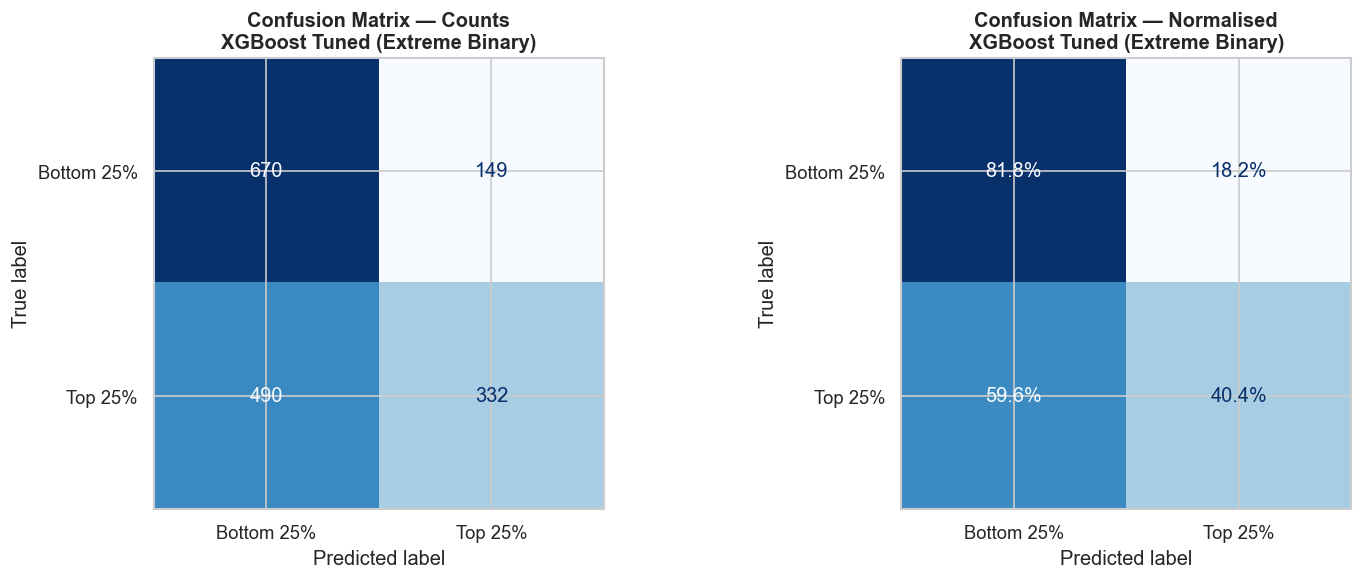

meta_ex re-saved with medians and modes

~~~~~~~~~~~~~~~~~~~~~~~~~~~
ARTIFACT SAVE CHECKLIST
~~~~~~~~~~~~~~~~~~~~~~~~~~~
  preprocessor.joblib                           FOUND
  model.joblib                                  FOUND
  xgb_model.joblib                              FOUND
  rf_regressor.joblib                           FOUND
  label_encoder.joblib                          FOUND
  inference_meta.joblib                         FOUND
  preprocessor_ex.joblib                        FOUND
  extreme_xgb_tuned.joblib                      FOUND
  inference_meta_ex.joblib                      FOUND
  engagement_sample.csv                         FOUND
  platform_hashtag_viral_rates.csv              FOUND
  feature_importance_summary.csv                FOUND
~~~~~~~~~~~~~~~~~~~~~~~~~~~

Best extreme model saved: XGBoost Tuned


In [20]:
# SHAP
print(f"{'~'*27}")
print("Computing SHAP values")
explainer = shap.TreeExplainer(best_xgb_clf)
X_test_df = pd.DataFrame(X_test[:500], columns=feat_names)
shap_values = explainer(X_test_df)
high_idx = list(lab_enc.classes_).index("High")
print(f"SHAP values shape: {shap_values.values.shape}")
print(f"High class index: {high_idx}  |  Classes: {list(lab_enc.classes_)}")

# Final confusion matrix
cm_final = confusion_matrix(y_ex_test, y_pred_best_ex)
tn, fp, fn, tp = cm_final.ravel()
print(f"\n{'~'*27}")
print(f"Final Confusion Matrix (Tuned XGBoost — Extreme Binary):")
print(f"{'~'*27}")
print(f"TN={tn}  FP={fp}")
print(f"FN={fn}  TP={tp}")
print(f"Precision: {tp/(tp+fp):.4f}")
print(f"Recall: {tp/(tp+fn):.4f}")
print(f"F1: {2*tp/(2*tp+fp+fn):.4f}")
print(f"{'~'*27}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=["Bottom 25%","Top 25%"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix — Counts\nXGBoost Tuned (Extreme Binary)", fontweight="bold")
cm_norm = cm_final.astype(float) / cm_final.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=["Bottom 25%","Top 25%"]).plot(ax=axes[1], cmap="Blues", colorbar=False, values_format=".1%")
axes[1].set_title("Confusion Matrix — Normalised\nXGBoost Tuned (Extreme Binary)", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(Other_imp_byproducts,"final_confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# SAVE ALL ARTIFACTS FOR app.py
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
os.makedirs(Other_imp_byproducts, exist_ok=True)

# Main 3-class preprocessor & models
joblib.dump(preprocessor, os.path.join(Other_imp_byproducts, "preprocessor.joblib"))
joblib.dump(classifiers["Logistic Regression"], os.path.join(Other_imp_byproducts, "model.joblib"))
joblib.dump(classifiers["XGBoost"], os.path.join(Other_imp_byproducts, "xgb_model.joblib"))
joblib.dump(best_rf_reg, os.path.join(Other_imp_byproducts, "rf_regressor.joblib"))
joblib.dump(lab_enc, os.path.join(Other_imp_byproducts, "label_encoder.joblib"))

# inference_meta - main
meta = {
    "cat_cols_ml":    cat_cols,
    "num_cols_ml":    num_cols,
    "label_classes":  list(lab_enc.classes_),
    "known_hashtags": list(df["primary_hashtag"].unique()),
    "raw_medians":    df[num_cols].median().to_dict(),
    "raw_modes":      {c: df[c].mode()[0] for c in cat_cols},
    "low_thresh":     low_thresh,
    "high_thresh":    high_thresh,
}
joblib.dump(meta, os.path.join(Other_imp_byproducts, "inference_meta.joblib"))

# Extreme binary preprocessor & best model
joblib.dump(preprocessor_ex, os.path.join(Other_imp_byproducts, "preprocessor_ex.joblib"))
joblib.dump(best_extreme_model, os.path.join(Other_imp_byproducts, "extreme_xgb_tuned.joblib"))

# inference_meta_ex
meta_ex = {
    "q25":         q25,
    "q75":         q75,
    "cat_cols_ex": cat_cols_ex,
    "num_cols_ex": num_cols_ex,
    # Add these two — fallbacks for app.py inference
    "raw_medians_ex": df_extreme[num_cols_ex].median().to_dict(),
    "raw_modes_ex":   {c: df_extreme[c].mode()[0] for c in cat_cols_ex},
}
joblib.dump(meta_ex, os.path.join(Other_imp_byproducts, "inference_meta_ex.joblib"))
print("meta_ex re-saved with medians and modes")

# CSVs needed by app.py
# engagement_sample.csv
df.sample(min(2000, len(df)), random_state=42).to_csv(
    os.path.join(Other_imp_byproducts, "engagement_sample.csv"), index=False)

# platform_hashtag_viral_rates.csv
viral_rates = (df.groupby(["primary_hashtag", "platform"])
               .apply(lambda x: (x["engagement_rate"] >= q75).mean())
               .reset_index(name="viral_rate"))
viral_rates.to_csv(os.path.join(Other_imp_byproducts, "platform_hashtag_viral_rates.csv"), index=False)

# feature_importance_summary.csv — use best_extreme_model if XGBoost, else fallback to classifiers XGBoost
if hasattr(best_extreme_model, "feature_importances_"):
    fi_scores = best_extreme_model.feature_importances_
    fi_names  = list(preprocessor_ex.get_feature_names_out())
else:
    fi_scores = classifiers["XGBoost"].feature_importances_
    fi_names  = list(preprocessor.get_feature_names_out())

fi_df = (pd.DataFrame({"feature": fi_names, "importance": fi_scores})
         .sort_values("importance", ascending=False)
         .head(20))
fi_df.to_csv(os.path.join(Other_imp_byproducts, "feature_importance_summary.csv"), index=False)

# Verify everything is saved
required = [
    "preprocessor.joblib", "model.joblib", "xgb_model.joblib",
    "rf_regressor.joblib", "label_encoder.joblib", "inference_meta.joblib",
    "preprocessor_ex.joblib", "extreme_xgb_tuned.joblib", "inference_meta_ex.joblib",
    "engagement_sample.csv", "platform_hashtag_viral_rates.csv",
    "feature_importance_summary.csv",
]
saved = os.listdir(Other_imp_byproducts)
print("\n" + "~" * 27)
print("ARTIFACT SAVE CHECKLIST")
print("~" * 27)
for f in required:
    status = "FOUND" if f in saved else "MISSING"
    print(f"  {f:<45} {status}")
print("~" * 27)
print(f"\nBest extreme model saved: {best_extreme_model_name}")

## Extra Figures For Report

~~~~~~~~~~~~~~~~~~~~~~~~~~~
Report Figures — 4.8 to 5.8
~~~~~~~~~~~~~~~~~~~~~~~~~~~

Figure 4.8


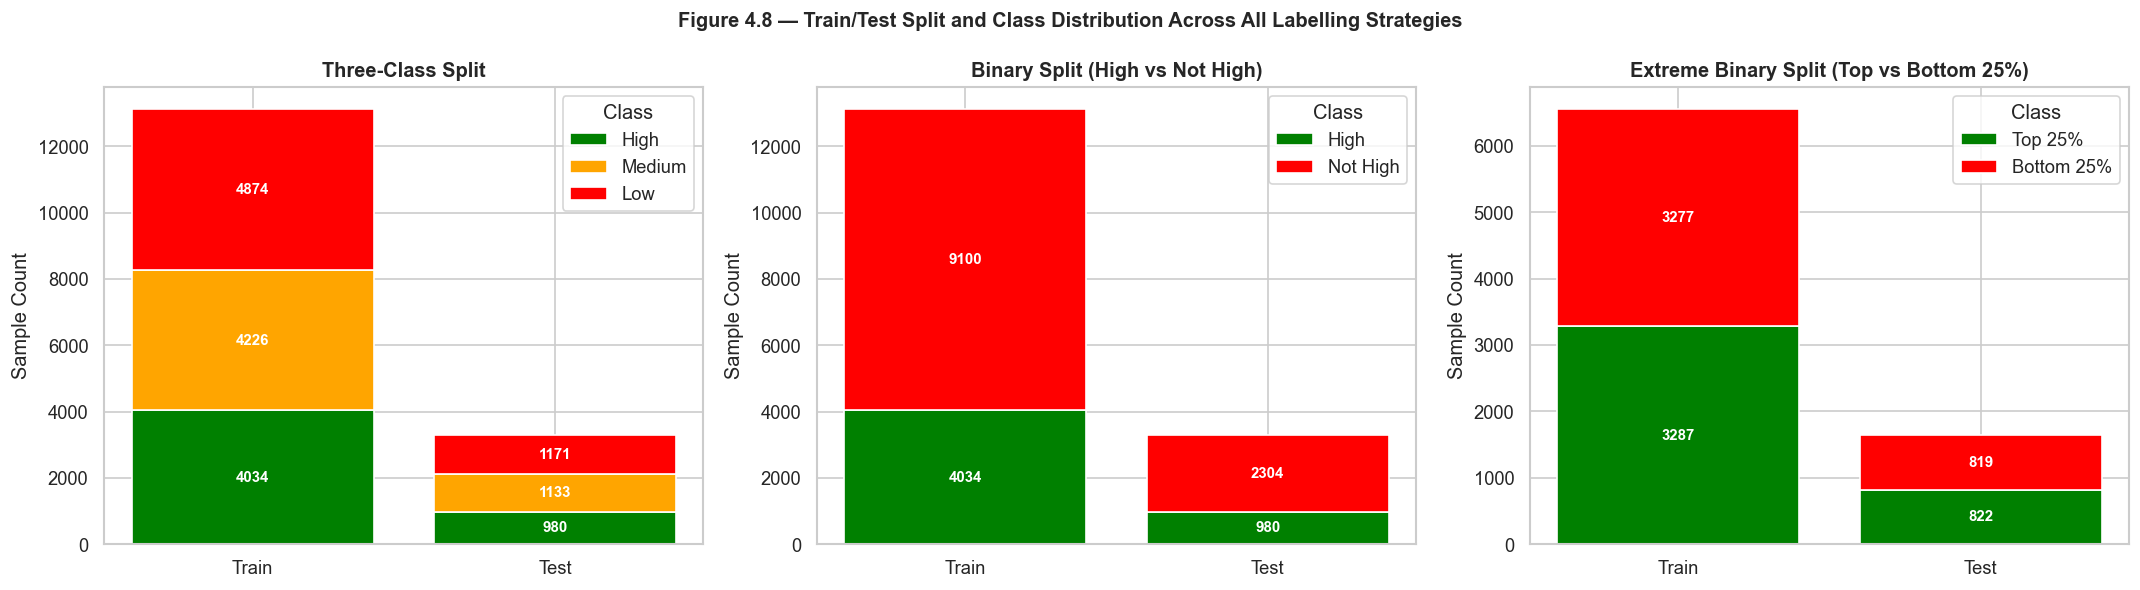


Figure 4.9


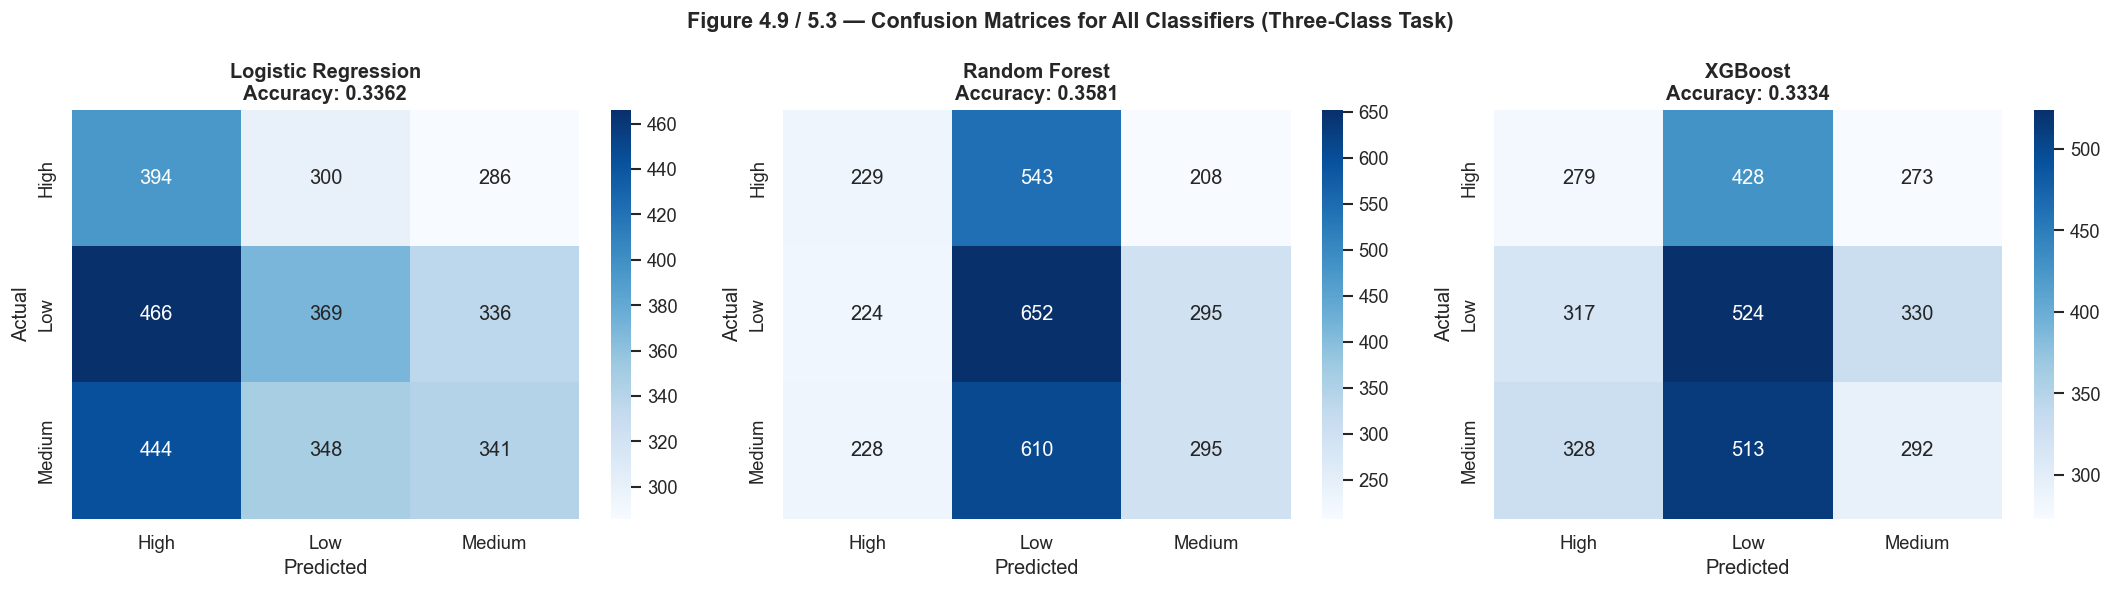


Figure 4.10


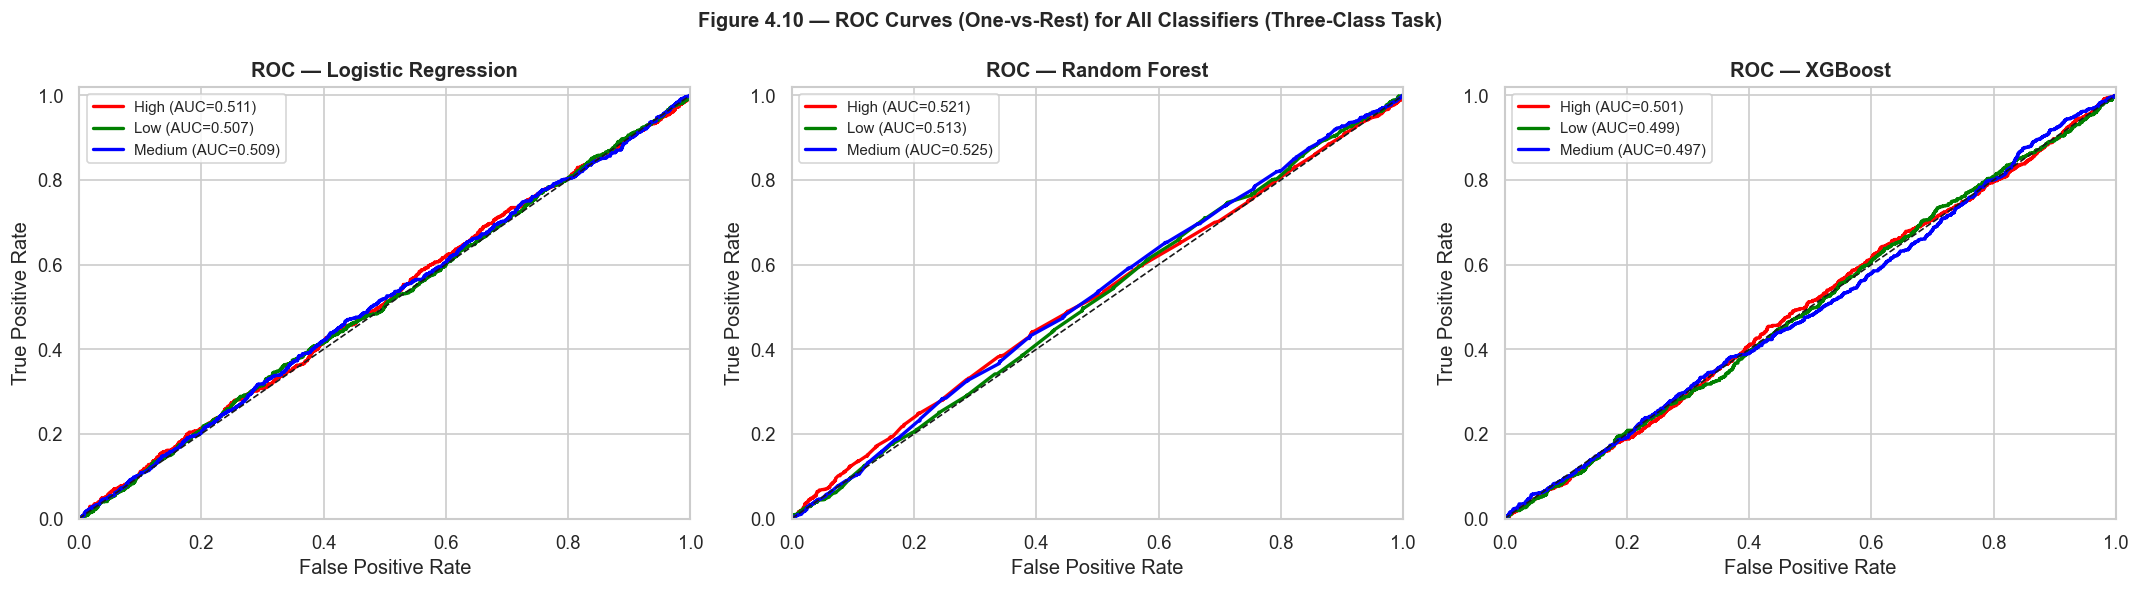


Figure 4.11


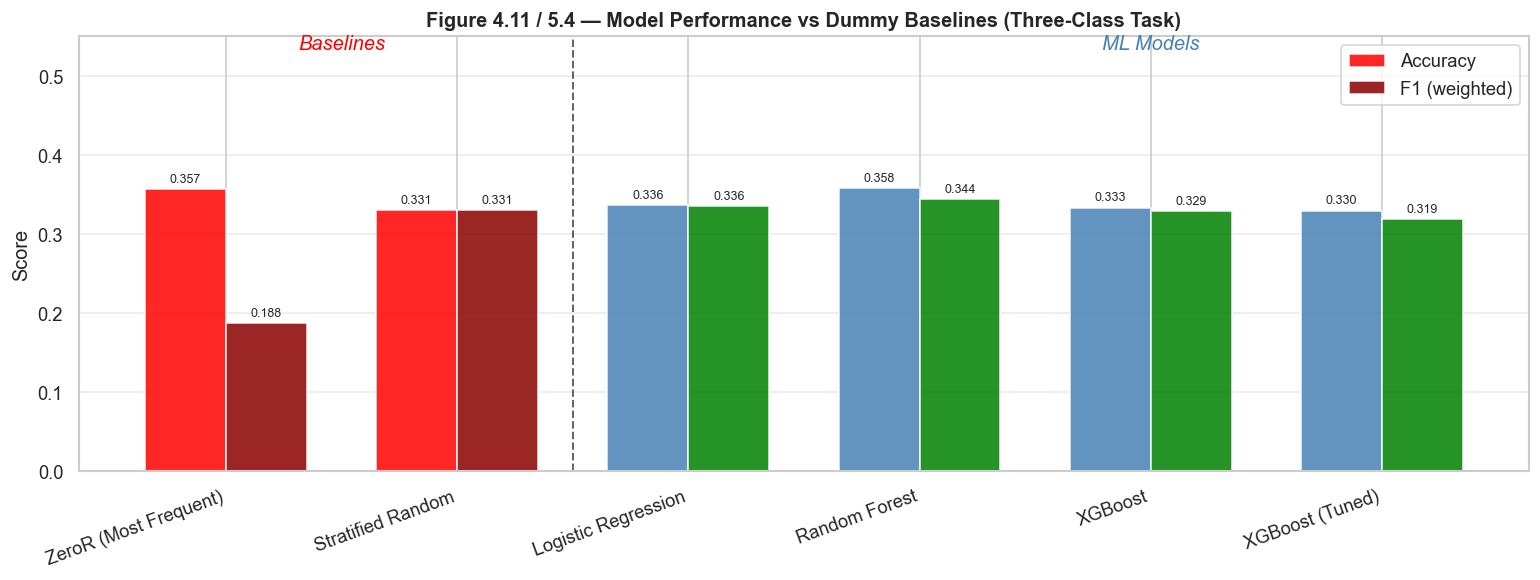


Figure 4.12


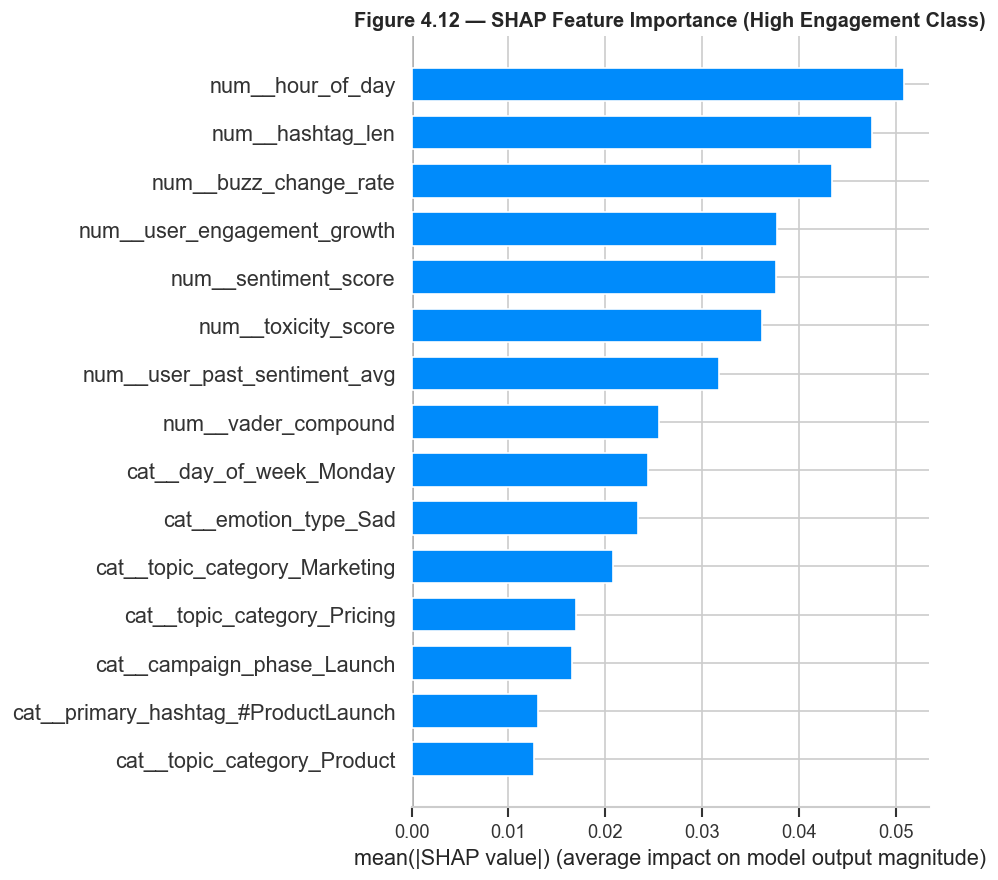


Figure 4.13


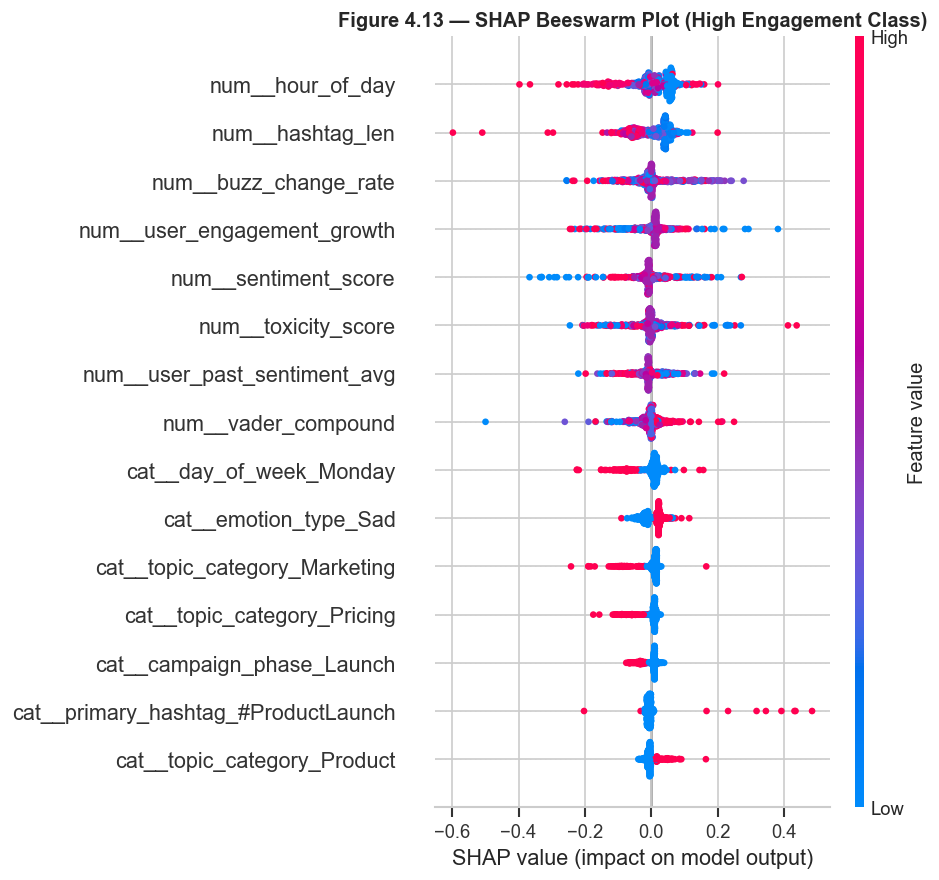


Figure 4.14


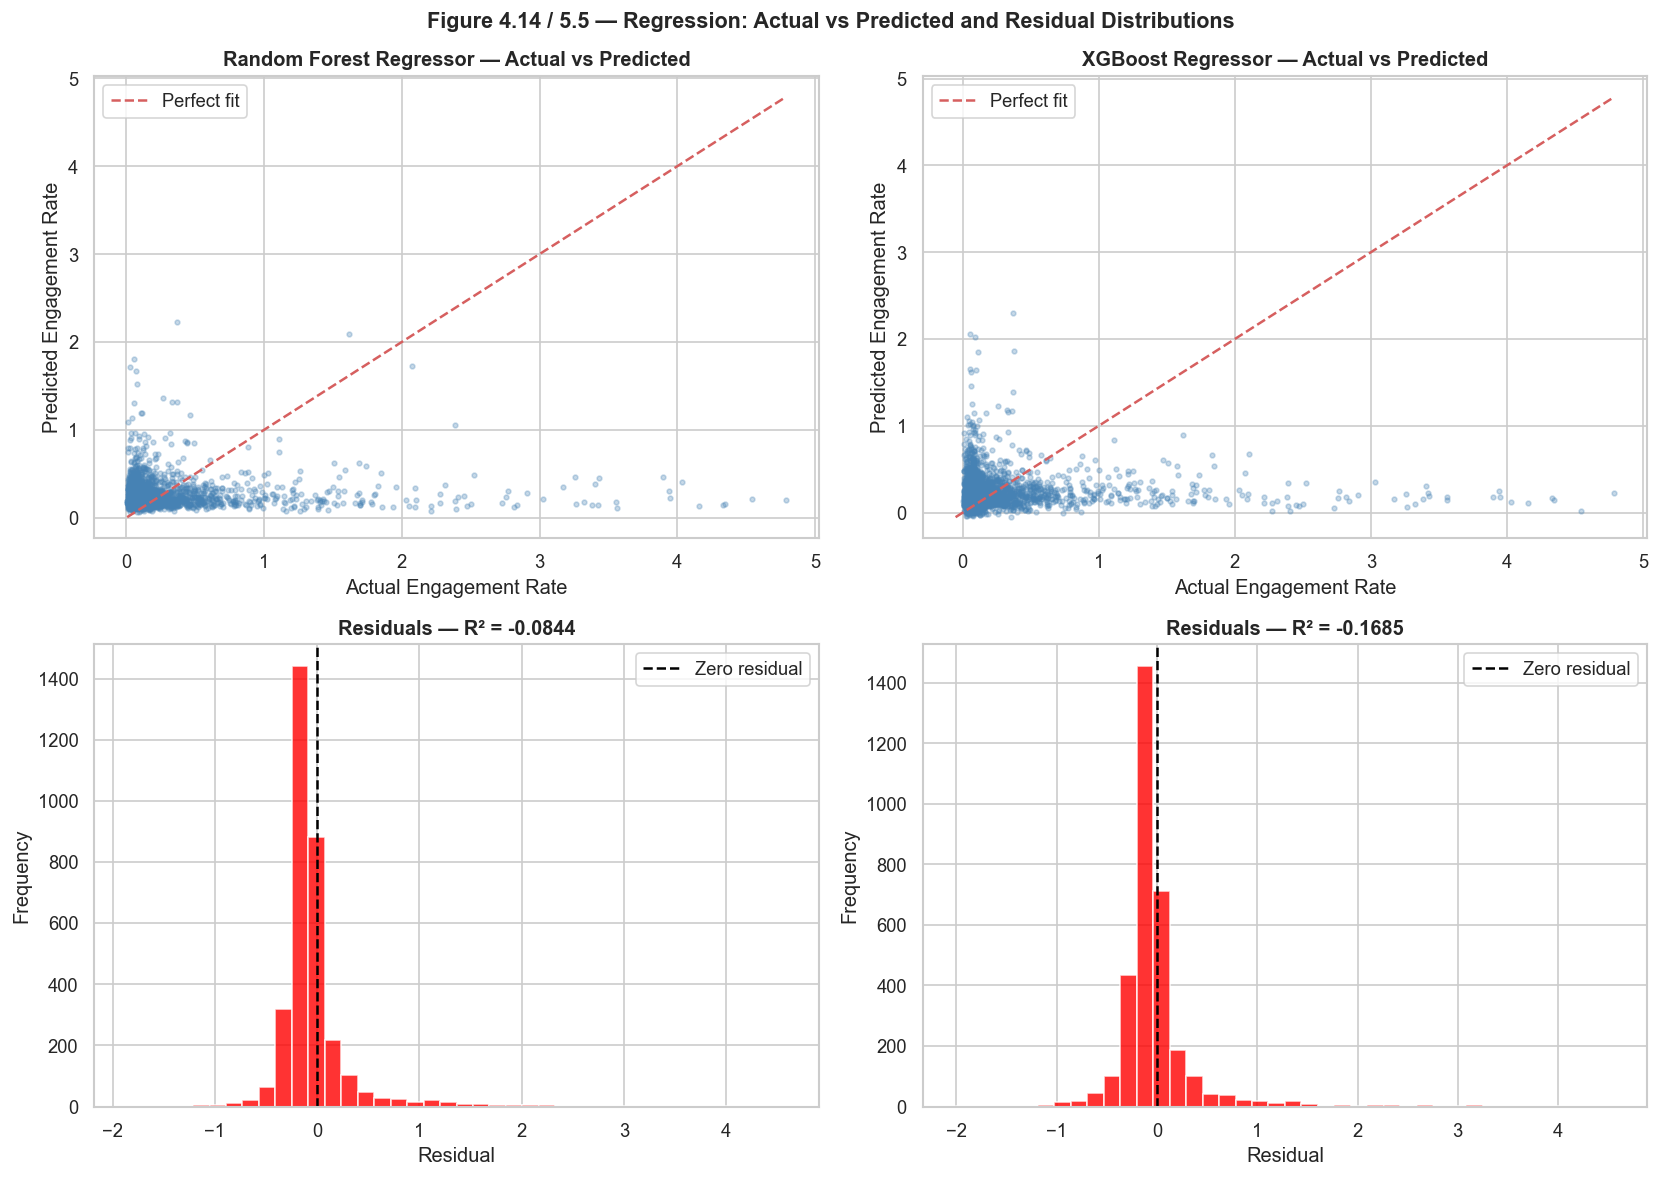


Figure 4.15


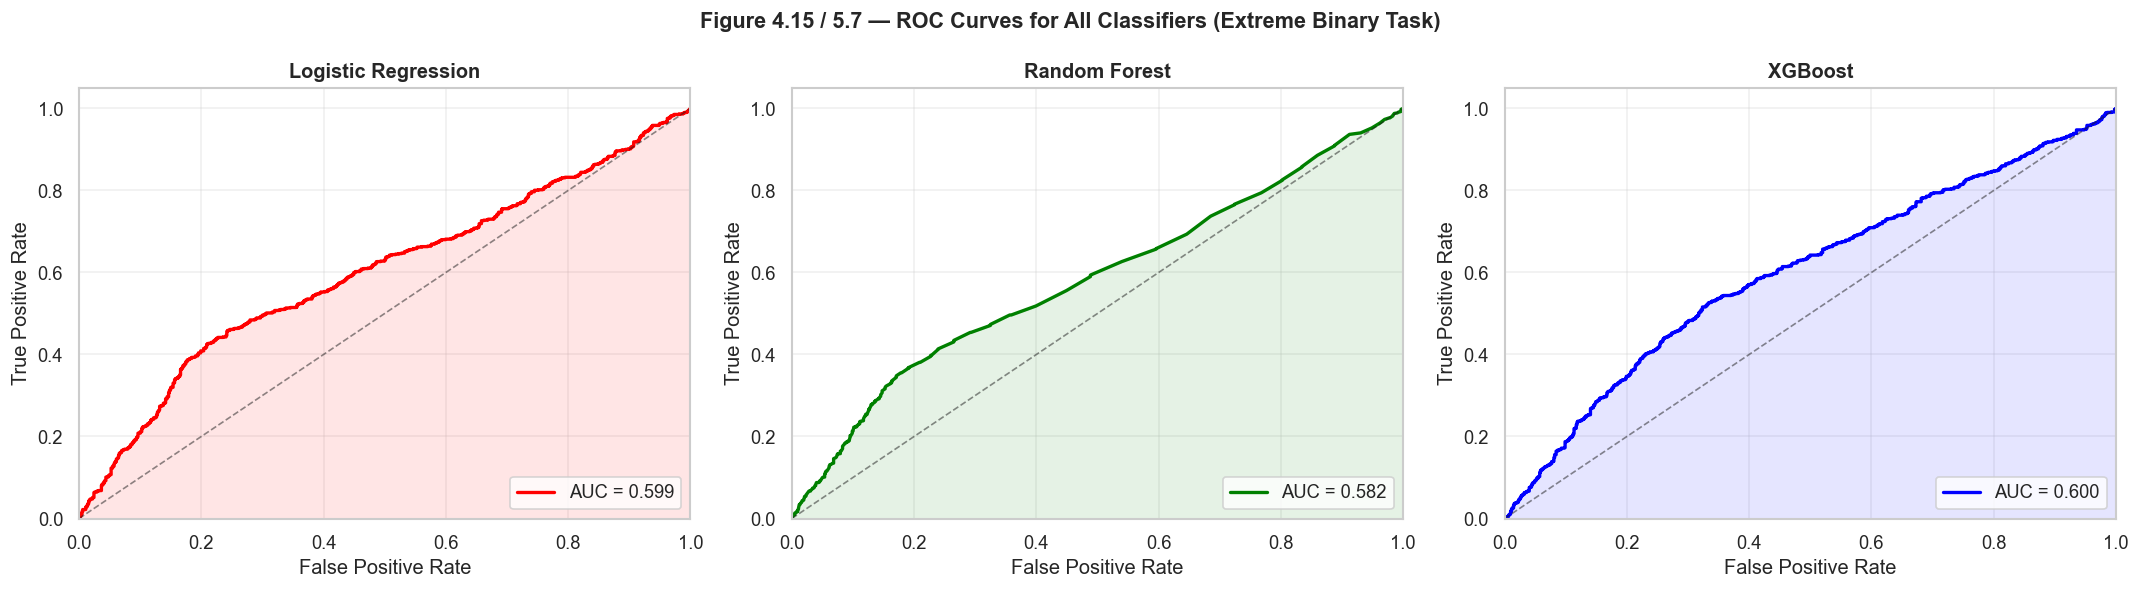


Figure 4.15b


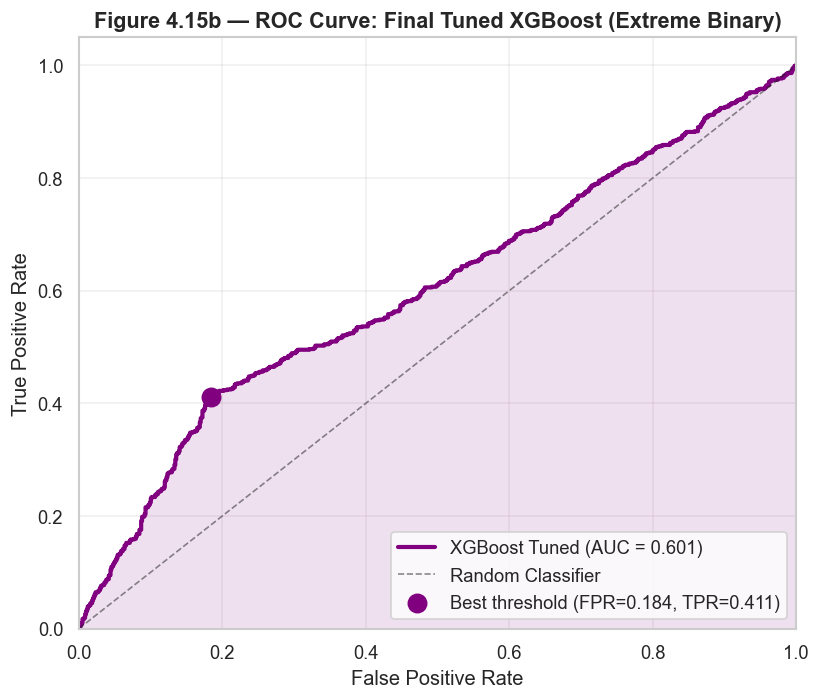


Figure 4.16


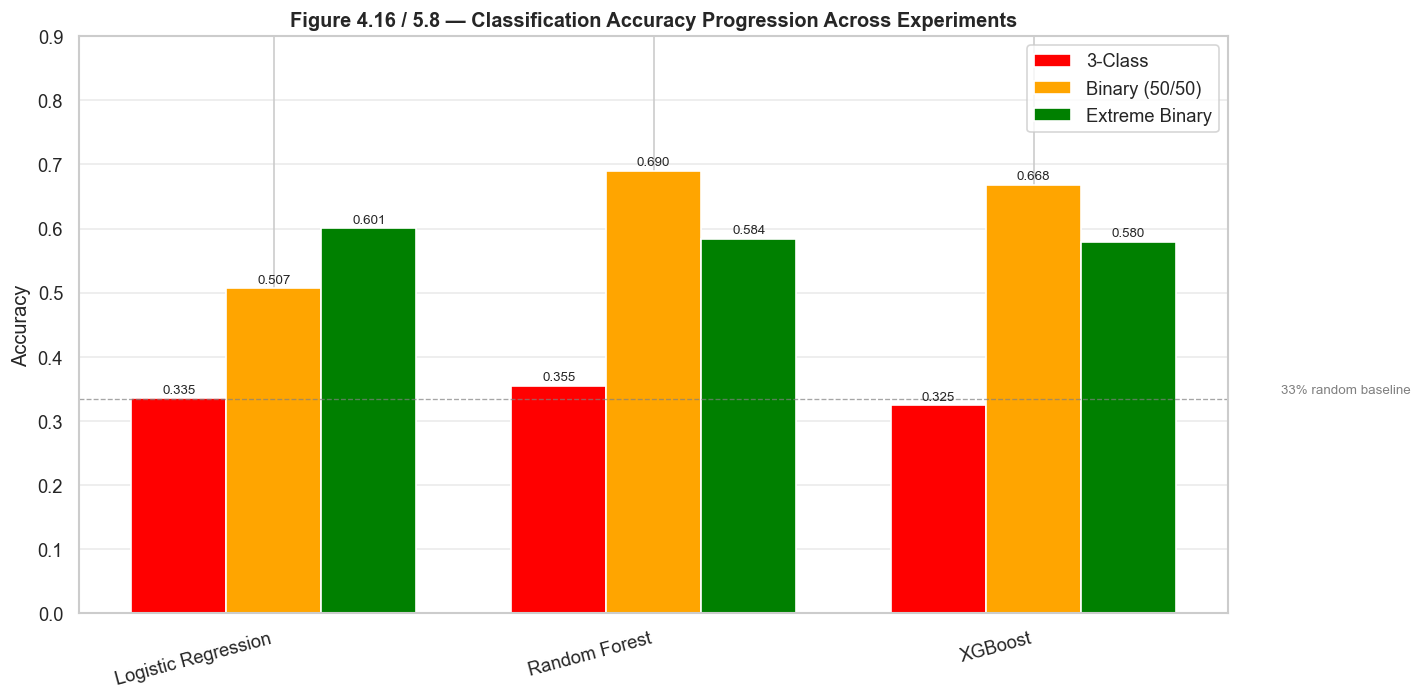


Figure 5.1


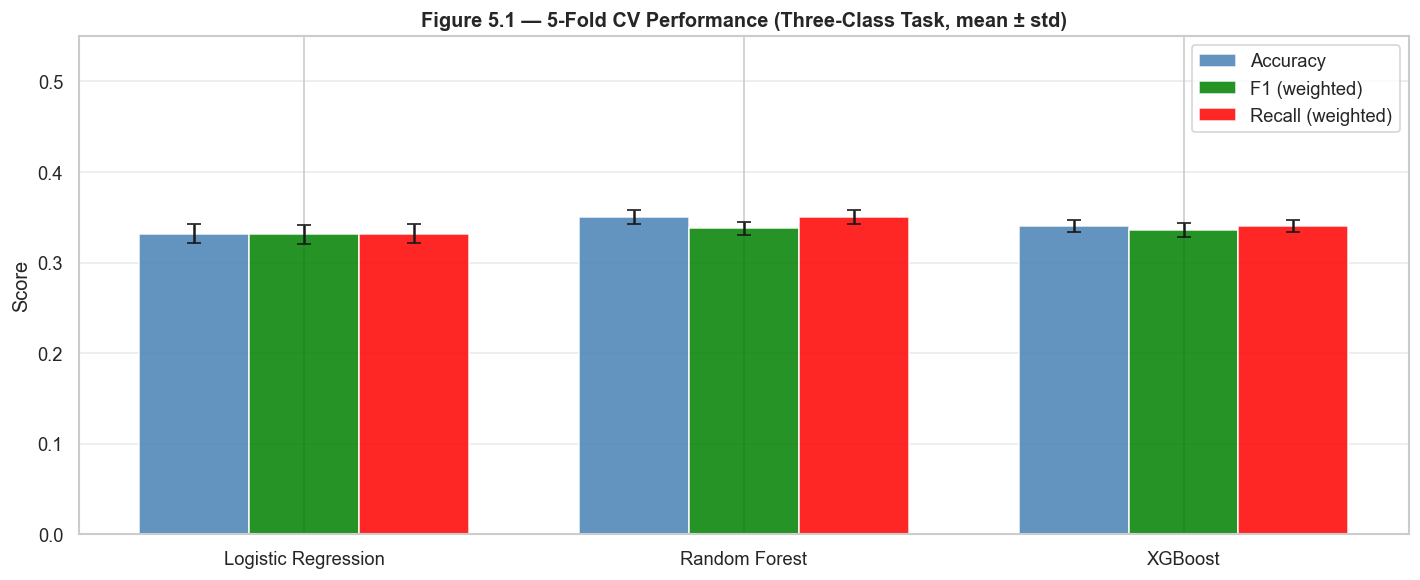


Figure 5.2


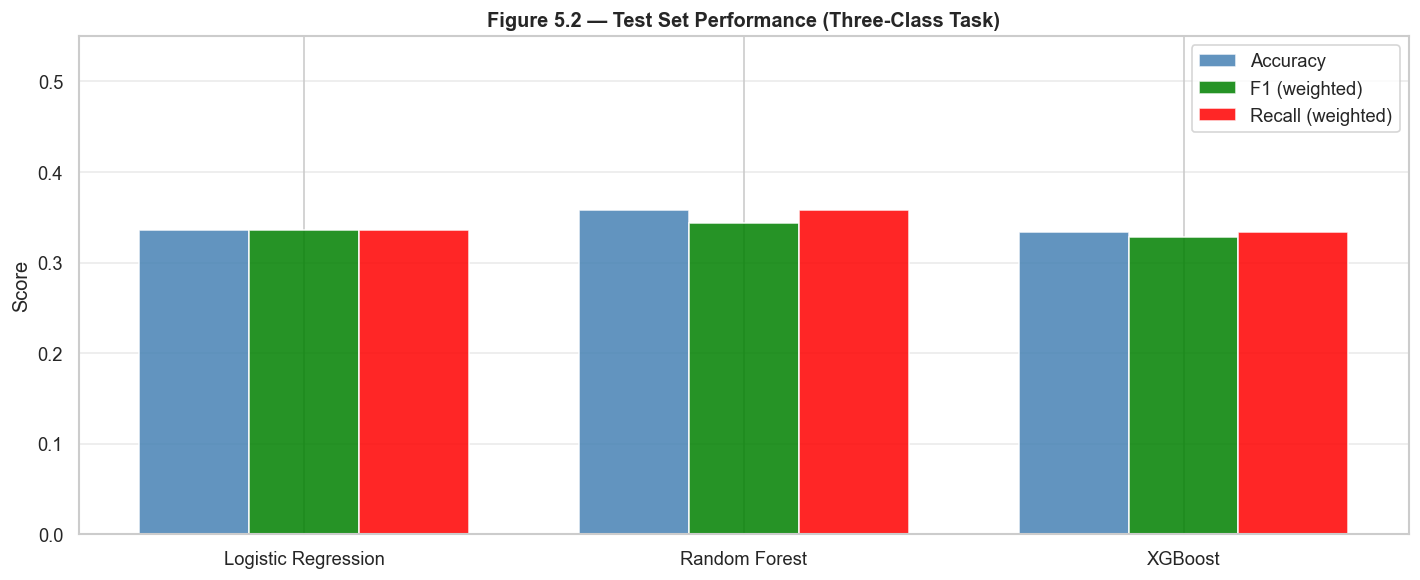


Figure 5.6


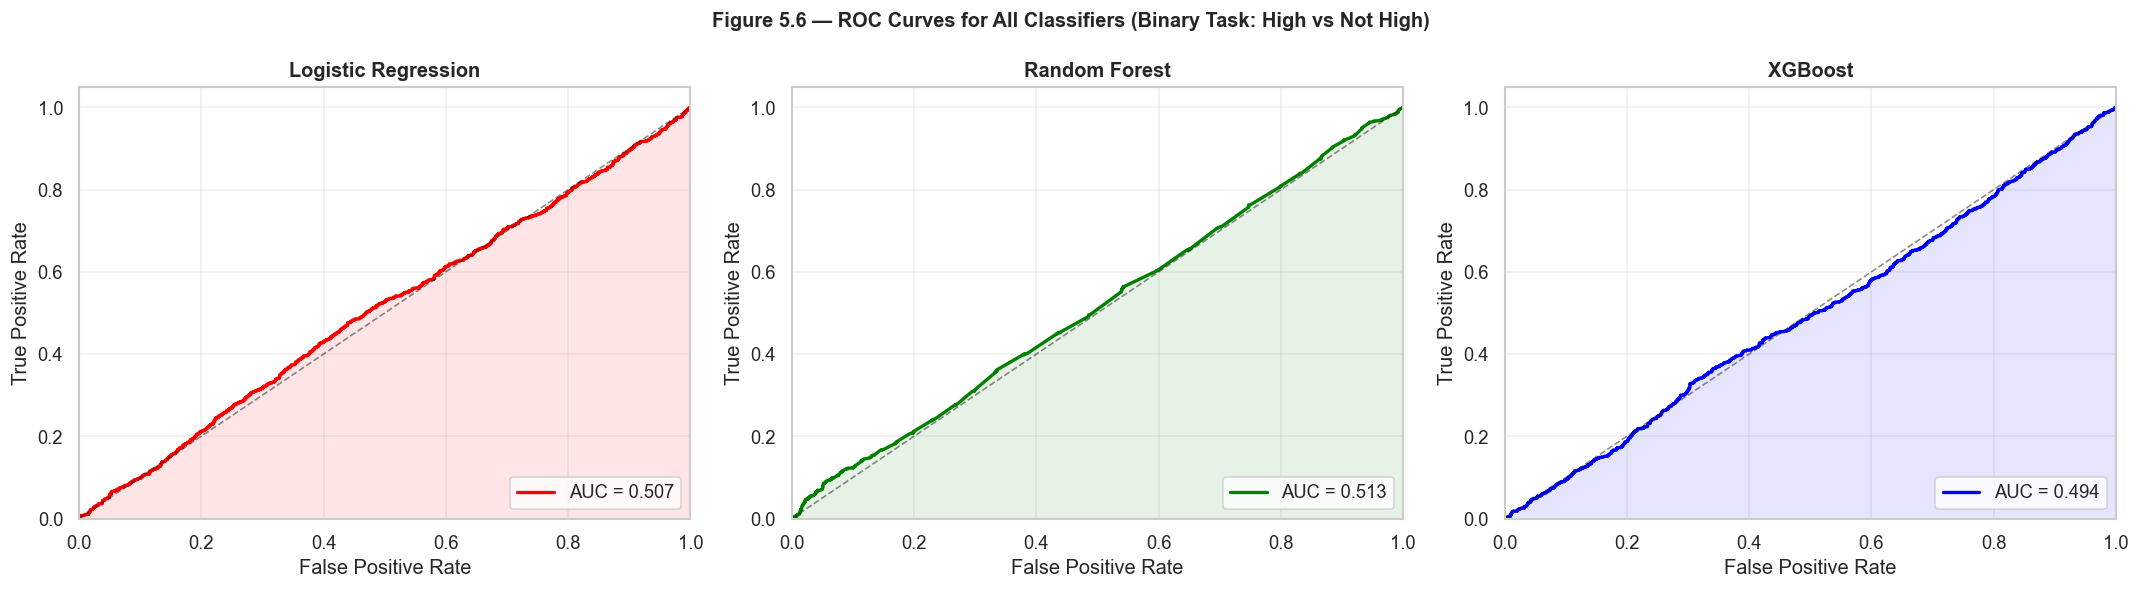


~~~~~~~~~~~~~~~~~~~~~~~~~~~
FINAL FIGURE CHECKLIST
~~~~~~~~~~~~~~~~~~~~~~~~~~~
Figure 4.1     FOUND
Figure 4.2     FOUND
Figure 4.3     FOUND
Figure 4.4     FOUND
Figure 4.5     FOUND
Figure 4.6     FOUND
Figure 4.7     FOUND
Figure 4.8     FOUND
Figure 4.9     FOUND
Figure 4.10    FOUND
Figure 4.11    FOUND
Figure 4.12    FOUND
Figure 4.13    FOUND
Figure 4.14    FOUND
Figure 4.15    FOUND
Figure 4.15b   FOUND
Figure 4.16    FOUND
Figure 5.1     FOUND
Figure 5.2     FOUND
Figure 5.3     FOUND
Figure 5.4     FOUND
Figure 5.5     FOUND
Figure 5.6     FOUND
Figure 5.7     FOUND
Figure 5.8     FOUND
~~~~~~~~~~~~~~~~~~~~~~~~~~~
~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [21]:
print("~" * 27)
print("Report Figures — 4.8 to 5.8")
print("~" * 27)

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Figure 4.8 — Train/Test Split Distribution
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
print("\nFigure 4.8")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

levels      = ["High", "Medium", "Low"]
colors      = ["green", "orange", "red"]

# Three-class split
train_counts = df.loc[train_idx, "Engagement_Level"].value_counts().reindex(levels, fill_value=0)
test_counts  = df.loc[test_idx,  "Engagement_Level"].value_counts().reindex(levels, fill_value=0)

bottom_train, bottom_test = 0, 0
for i, level in enumerate(levels):
    tv  = train_counts[level]
    tev = test_counts[level]
    axes[0].bar("Train", tv,  bottom=bottom_train, color=colors[i], label=level)
    axes[0].bar("Test",  tev, bottom=bottom_test,  color=colors[i])
    axes[0].text(0, bottom_train + tv  / 2, str(tv),  ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    axes[0].text(1, bottom_test  + tev / 2, str(tev), ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    bottom_train += tv
    bottom_test  += tev
axes[0].set_title("Three-Class Split")
axes[0].set_ylabel("Sample Count")
axes[0].legend(title="Class")

# Binary split - High vs Not High
def to_binary(x):
    return "High" if x == "High" else "Not High"

bin_levels  = ["High", "Not High"]
bin_colors  = ["green", "red"]
train_bin   = df.loc[train_idx, "Engagement_Level"].apply(to_binary).value_counts().reindex(bin_levels, fill_value=0)
test_bin    = df.loc[test_idx,  "Engagement_Level"].apply(to_binary).value_counts().reindex(bin_levels, fill_value=0)

bottom_train, bottom_test = 0, 0
for i, level in enumerate(bin_levels):
    tv  = train_bin[level]
    tev = test_bin[level]
    axes[1].bar("Train", tv,  bottom=bottom_train, color=bin_colors[i], label=level)
    axes[1].bar("Test",  tev, bottom=bottom_test,  color=bin_colors[i])
    axes[1].text(0, bottom_train + tv  / 2, str(tv),  ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    axes[1].text(1, bottom_test  + tev / 2, str(tev), ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    bottom_train += tv
    bottom_test  += tev
axes[1].set_title("Binary Split (High vs Not High)")
axes[1].set_ylabel("Sample Count")
axes[1].legend(title="Class")

# Extreme binary split - Top 25% vs Bottom 25%
ex_labels  = {1: "Top 25%", 0: "Bottom 25%"}
ex_colors  = {1: "green",   0: "red"}
ex_train_counts = pd.Series(y_ex_train).value_counts()
ex_test_counts  = pd.Series(y_ex_test).value_counts()

bottom_train, bottom_test = 0, 0
for cls in [1, 0]:
    tv  = ex_train_counts.get(cls, 0)
    tev = ex_test_counts.get(cls, 0)
    axes[2].bar("Train", tv,  bottom=bottom_train, color=ex_colors[cls], label=ex_labels[cls])
    axes[2].bar("Test",  tev, bottom=bottom_test,  color=ex_colors[cls])
    axes[2].text(0, bottom_train + tv  / 2, str(tv),  ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    axes[2].text(1, bottom_test  + tev / 2, str(tev), ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    bottom_train += tv
    bottom_test  += tev
axes[2].set_title("Extreme Binary Split (Top vs Bottom 25%)")
axes[2].set_ylabel("Sample Count")
axes[2].legend(title="Class")

fig.suptitle("Figure 4.8 — Train/Test Split and Class Distribution Across All Labelling Strategies", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(Other_imp_byproducts, "Figure_4_8_split_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Figure 4.9 — Confusion Matrices (Three-Class)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
print("\nFigure 4.9")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, clf) in zip(axes, classifiers.items()):
    y_pred = clf.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=lab_enc.classes_,
                yticklabels=lab_enc.classes_)
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f"{name}\nAccuracy: {acc:.4f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

fig.suptitle("Figure 4.9 / 5.3 — Confusion Matrices for All Classifiers (Three-Class Task)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(Other_imp_byproducts, "Figure_4_9_5_3_confusion_3class.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Figure 4.10 — ROC Curves (Three-Class, One vs Rest)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
print("\nFigure 4.10")

y_test_bin  = label_binarize(y_test, classes=[0, 1, 2])
classes_3   = lab_enc.classes_
roc_colors  = ["red", "green", "blue"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, clf) in zip(axes, classifiers.items()):
    y_score = clf.predict_proba(X_test)
    for i, (cls, col) in enumerate(zip(classes_3, roc_colors)):
        fpr_, tpr_, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc_      = auc(fpr_, tpr_)
        ax.plot(fpr_, tpr_, color=col, lw=2, label=f"{cls} (AUC={roc_auc_:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title(f"ROC — {name}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=9)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

fig.suptitle("Figure 4.10 — ROC Curves (One-vs-Rest) for All Classifiers (Three-Class Task)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(Other_imp_byproducts, "Figure_4_10_roc_3class.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Figure 4.11 — Model vs Dummy Baselines
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
print("\nFigure 4.11")

model_names = aug_df["Model"].tolist()
x_pos       = np.arange(len(model_names))
bar_width   = 0.35

# Different colour for baselines vs ML models
acc_colors = ["red"  if t == "Baseline" else "steelblue" for t in aug_df["Type"]]
f1_colors  = ["darkred" if t == "Baseline" else "green"  for t in aug_df["Type"]]

fig, ax = plt.subplots(figsize=(13, 5))

bars1 = ax.bar(x_pos - bar_width / 2, aug_df["Accuracy"],    bar_width, label="Accuracy",      color=acc_colors, alpha=0.85)
bars2 = ax.bar(x_pos + bar_width / 2, aug_df["F1 weighted"], bar_width, label="F1 (weighted)", color=f1_colors,  alpha=0.85)

# Add value labels on bars
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=7.5)

# Divider line between baselines and models
ax.axvline(x=1.5, color="black", linestyle="--", lw=1.2, alpha=0.6)
ax.text(0.5,  0.97, "Baselines", transform=ax.get_xaxis_transform(), ha="center", color="red",      fontstyle="italic")
ax.text(4.0,  0.97, "ML Models", transform=ax.get_xaxis_transform(), ha="center", color="steelblue", fontstyle="italic")

ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, rotation=20, ha="right")
ax.set_ylim(0, 0.55)
ax.set_ylabel("Score")
ax.legend()
ax.grid(axis="y", alpha=0.4)
ax.set_title("Figure 4.11 / 5.4 — Model Performance vs Dummy Baselines (Three-Class Task)", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(Other_imp_byproducts, "Figure_4_11_5_4_baselines.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Figure 4.12 — SHAP Feature Importance (Bar)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
print("\nFigure 4.12")

plt.figure()
shap.summary_plot(shap_values.values[:, :, high_idx], X_test_df,
                  max_display=15, show=False, plot_type="bar")
plt.title("Figure 4.12 — SHAP Feature Importance (High Engagement Class)")
plt.tight_layout()
plt.savefig(os.path.join(Other_imp_byproducts, "Figure_4_12_shap_importance.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Figure 4.13 — SHAP Beeswarm Plot
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
print("\nFigure 4.13")

plt.figure()
shap.summary_plot(shap_values.values[:, :, high_idx], X_test_df,
                  max_display=15, show=False)
plt.title("Figure 4.13 — SHAP Beeswarm Plot (High Engagement Class)")
plt.tight_layout()
plt.savefig(os.path.join(Other_imp_byproducts, "Figure_4_13_shap_beeswarm.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Figure 4.14 — Regression Actual vs Predicted + Residuals
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
print("\nFigure 4.14")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (name, reg) in enumerate(regressors.items()):
    y_pred_r  = reg.predict(X_test)
    residuals = y_reg_test - y_pred_r
    r2        = r2_score(y_reg_test, y_pred_r)

    # Actual vs predicted scatter
    lims = [min(y_reg_test.min(), y_pred_r.min()),
            max(y_reg_test.max(), y_pred_r.max())]
    axes[0][i].scatter(y_reg_test, y_pred_r, alpha=0.3, s=8, color="steelblue")
    axes[0][i].plot(lims, lims, "r--", lw=1.5, label="Perfect fit")
    axes[0][i].set_title(f"{name} — Actual vs Predicted")
    axes[0][i].set_xlabel("Actual Engagement Rate")
    axes[0][i].set_ylabel("Predicted Engagement Rate")
    axes[0][i].legend()

    # Residuals histogram
    axes[1][i].hist(residuals, bins=40, color="red", edgecolor="white", alpha=0.8)
    axes[1][i].axvline(0, color="black", linestyle="--", lw=1.5, label="Zero residual")
    axes[1][i].set_title(f"Residuals — R² = {r2:.4f}")
    axes[1][i].set_xlabel("Residual")
    axes[1][i].set_ylabel("Frequency")
    axes[1][i].legend()

fig.suptitle("Figure 4.14 / 5.5 — Regression: Actual vs Predicted and Residual Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(Other_imp_byproducts, "Figure_4_14_5_5_regression_plots.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Figure 4.15 — ROC Curves (Extreme Binary, All Models)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
print("\nFigure 4.15")

roc_colors_ex = ["red", "green", "blue"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, (fpr_, tpr_, roc_auc_)) in enumerate(roc_data.items()):
    ax = axes[idx]
    ax.plot(fpr_, tpr_, color=roc_colors_ex[idx], lw=2, label=f"AUC = {roc_auc_:.3f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    ax.fill_between(fpr_, tpr_, alpha=0.1, color=roc_colors_ex[idx])
    ax.set_title(name)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.grid(alpha=0.3)

fig.suptitle("Figure 4.15 / 5.7 — ROC Curves for All Classifiers (Extreme Binary Task)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(Other_imp_byproducts, "Figure_4_15_5_7_roc_extreme.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Figure 4.15b — Final Tuned XGBoost ROC with Optimal Threshold
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
print("\nFigure 4.15b")

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr_ex, tpr_ex, color="purple", lw=2.5, label=f"XGBoost Tuned (AUC = {roc_auc_ex:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random Classifier")
ax.fill_between(fpr_ex, tpr_ex, alpha=0.12, color="purple")

# Mark the best threshold point (maximises TPR - FPR)
best_idx = np.argmax(tpr_ex - fpr_ex)
ax.scatter(fpr_ex[best_idx], tpr_ex[best_idx], s=120, color="purple", zorder=5,
           label=f"Best threshold (FPR={fpr_ex[best_idx]:.3f}, TPR={tpr_ex[best_idx]:.3f})")

ax.set_title("Figure 4.15b — ROC Curve: Final Tuned XGBoost (Extreme Binary)", fontsize=13, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(Other_imp_byproducts, "Figure_4_15b_roc_tuned_xgb.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Figure 4.16 — Accuracy Progression Across Experiments
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
print("\nFigure 4.16")

# Get extreme binary accuracy values for each model
ex_acc = {}
for m in ["Logistic Regression", "Random Forest", "XGBoost"]:
    val = extreme_df.loc[extreme_df["Model"] == m, "Accuracy"].values
    ex_acc[m] = val[0] if len(val) > 0 else 0.0

progression = pd.DataFrame({
    "Model":          ["Logistic Regression", "Random Forest", "XGBoost"],
    "3-Class":        [0.3350, 0.3548, 0.3249],
    "Binary (50/50)": [0.5070, 0.6900, 0.6684],
    "Extreme Binary": [ex_acc["Logistic Regression"],
                       ex_acc["Random Forest"],
                       ex_acc["XGBoost"]],
})

x_pos     = np.arange(len(progression))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x_pos - bar_width, progression["3-Class"],        bar_width, label="3-Class",        color="red")
bars2 = ax.bar(x_pos,             progression["Binary (50/50)"], bar_width, label="Binary (50/50)", color="orange")
bars3 = ax.bar(x_pos + bar_width, progression["Extreme Binary"], bar_width, label="Extreme Binary", color="green")

# Value labels on each bar
for bar in list(bars1) + list(bars2) + list(bars3):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.008,
            f"{bar.get_height():.3f}",
            ha="center", fontsize=8)

# 33% random baseline reference line
ax.axhline(y=1/3, linestyle="--", color="gray", lw=0.8, alpha=0.7)
ax.text(2.65, 1/3 + 0.01, "33% random baseline", fontsize=8, color="gray")

ax.set_xticks(x_pos)
ax.set_xticklabels(progression["Model"], rotation=15, ha="right")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 0.90)
ax.legend()
ax.grid(axis="y", alpha=0.4)
ax.set_title("Figure 4.16 / 5.8 — Classification Accuracy Progression Across Experiments", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(Other_imp_byproducts, "Figure_4_16_5_8_accuracy_progression.png"), dpi=150)
plt.show()
plt.close()

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Figure 5.1 — 5-Fold CV Performance (Three-Class)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
print("\nFigure 5.1")

# Parse CV results from stored list
cv_names  = [r["Model"]      for r in cv_results]
cv_acc_m  = [float(r["CV Accuracy"].split(" ")[0])   for r in cv_results]
cv_acc_s  = [float(r["CV Accuracy"].split("+/-")[1]) for r in cv_results]
cv_f1_m   = [float(r["CV F1"].split(" ")[0])         for r in cv_results]
cv_f1_s   = [float(r["CV F1"].split("+/-")[1])       for r in cv_results]
cv_rec_m  = [float(r["CV Recall"].split(" ")[0])     for r in cv_results]
cv_rec_s  = [float(r["CV Recall"].split("+/-")[1])   for r in cv_results]

x_pos     = np.arange(len(cv_names))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x_pos - bar_width, cv_acc_m, bar_width, yerr=cv_acc_s, capsize=4, label="Accuracy",         color="steelblue", alpha=0.85)
ax.bar(x_pos,             cv_f1_m,  bar_width, yerr=cv_f1_s,  capsize=4, label="F1 (weighted)",    color="green",     alpha=0.85)
ax.bar(x_pos + bar_width, cv_rec_m, bar_width, yerr=cv_rec_s, capsize=4, label="Recall (weighted)",color="red",       alpha=0.85)

ax.set_xticks(x_pos)
ax.set_xticklabels(cv_names)
ax.set_ylim(0, 0.55)
ax.set_ylabel("Score")
ax.legend()
ax.grid(axis="y", alpha=0.4)
ax.set_title("Figure 5.1 — 5-Fold CV Performance (Three-Class Task, mean ± std)", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(Other_imp_byproducts, "Figure_5_1_cv_3class.png"), dpi=150)
plt.show()
plt.close()

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Figure 5.2 — Test Set Performance (Three-Class)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
print("\nFigure 5.2")

# Exclude tuned model for fair comparison
test_rows = compdf[compdf["Model"] != "XGBoost Tuned"].reset_index(drop=True)
x_pos     = np.arange(len(test_rows))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x_pos - bar_width, test_rows["Accuracy"],        bar_width, label="Accuracy",         color="steelblue", alpha=0.85)
ax.bar(x_pos,             test_rows["F1 weighted"],     bar_width, label="F1 (weighted)",    color="green",     alpha=0.85)
ax.bar(x_pos + bar_width, test_rows["Recall weighted"], bar_width, label="Recall (weighted)", color="red",      alpha=0.85)

ax.set_xticks(x_pos)
ax.set_xticklabels(test_rows["Model"].tolist())
ax.set_ylim(0, 0.55)
ax.set_ylabel("Score")
ax.legend()
ax.grid(axis="y", alpha=0.4)
ax.set_title("Figure 5.2 — Test Set Performance (Three-Class Task)", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(Other_imp_byproducts, "Figure_5_2_test_3class.png"), dpi=150)
plt.show()
plt.close()


# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Figure 5.6 — ROC Curves (Binary Task: High vs Not High)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
print("\nFigure 5.6")

roc_colors_bin = ["red", "green", "blue"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, (fpr_, tpr_, roc_auc_)) in enumerate(roc_data_bin.items()):
    ax = axes[idx]
    ax.plot(fpr_, tpr_, color=roc_colors_bin[idx], lw=2, label=f"AUC = {roc_auc_:.3f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    ax.fill_between(fpr_, tpr_, alpha=0.1, color=roc_colors_bin[idx])
    ax.set_title(name)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.grid(alpha=0.3)

fig.suptitle("Figure 5.6 — ROC Curves for All Classifiers (Binary Task: High vs Not High)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(Other_imp_byproducts, "Figure_5_6_roc_binary.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()


# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Final Checklist — Check all figures saved
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
print("\n" + "~" * 27)
print("FINAL FIGURE CHECKLIST")
print("~" * 27)

all_figures = {
    "4.1":  "Figure_4_1", "4.2":  "Figure_4_2", "4.3":  "Figure_4_3",
    "4.4":  "Figure_4_4", "4.5":  "Figure_4_5", "4.6":  "Figure_4_6",
    "4.7":  "Figure_4_7", "4.8":  "Figure_4_8", "4.9":  "Figure_4_9",
    "4.10": "Figure_4_10","4.11": "Figure_4_11","4.12": "Figure_4_12",
    "4.13": "Figure_4_13","4.14": "Figure_4_14","4.15": "Figure_4_15",
    "4.15b":"Figure_4_15b","4.16":"Figure_4_16",
    "5.1":  "Figure_5_1", "5.2":  "Figure_5_2", "5.3":  "Figure_5_3",
    "5.4":  "Figure_5_4", "5.5":  "Figure_5_5", "5.6":  "Figure_5_6",
    "5.7":  "Figure_5_7", "5.8":  "Figure_5_8",
}

saved_files = os.listdir(Other_imp_byproducts)

for fig_num, prefix in all_figures.items():
    found = any(f.startswith(prefix) for f in saved_files)
    status = "FOUND" if found else "MISSING"
    print(f"Figure {fig_num:<6}  {status}")

print("~" * 27)
print("~" * 27)